In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time
import os
from adjustText import adjust_text
from nba_api.stats.static import players
from nba_api.stats.endpoints import (
    leaguedashplayerstats, leaguedashplayerclutch, playerawards,
)


In [110]:
pd.set_option('display.max_columns', None, 'display.max_rows', None)

## Data Collection
### Active player roster
`players.get_active_players()` reads a local static file — no network call.
Used here only as a denominator to show how many players the volume filter removes.

In [111]:
active_players_df = pd.DataFrame(players.get_active_players())
active_players_df.sample(5)


,id,full_name,first_name,last_name,is_active
99,1642359,Pacôme Dadiet,Pacôme,Dadiet,True
380,1641765,Olivier-Maxence Prosper,Olivier-Maxence,Prosper,True
362,1630590,Scotty Pippen Jr.,Scotty,Pippen Jr.,True
107,1631217,Moussa Diabaté,Moussa,Diabaté,True
484,1641716,Jarace Walker,Jarace,Walker,True


### Endpoint parameters
`seasons` is a generated list covering 2004-05 through 2025-26 — 22 seasons —
built with an f-string so no season string has to be typed by hand.
`"Advanced"` and `"Base"` are two measure types of the same endpoint: Advanced
gives rate/efficiency stats, Base gives counting stats. Both get pulled for
every season in the list below.

In [112]:
seasons = [f"{y}-{str(y+1)[-2:]}" for y in range(2004, 2026)]
reg_season = "Regular Season"
advanced_stats = "Advanced"
basic_stats = "Base"

print(f"{len(seasons)} seasons: {seasons[0]} to {seasons[-1]}")

22 seasons: 2004-05 to 2025-26


### Season stats — Advanced
Source for TS%, eFG%, USG%, Net Rating, PIE — pulled once per season across
all 22 seasons via `fetch_all_seasons`, then cached to Parquet so this never
has to re-run.

**Scale warning:** percentage columns aren't consistently scaled — some come
back as whole numbers, some as decimals. Always run `.describe()` before
binning a column; a scale mismatch doesn't error, it silently produces empty bins.

*`MIN` here is per-game. In the Base frame it's a season total — don't mix them.*

In [113]:
def fetch_all_seasons(measure_type, cache_path):
    if os.path.exists(cache_path):
        out_df = pd.read_parquet(cache_path)
        print(f"Loaded {len(out_df)} rows from cache")
        return out_df

    frames = []
    for i, season in enumerate(seasons, start=1):
        stats = leaguedashplayerstats.LeagueDashPlayerStats(
            season=season,
            season_type_all_star=reg_season,
            measure_type_detailed_defense=measure_type
        )
        season_stats_df = stats.get_data_frames()[0]
        season_stats_df['SEASON'] = season
        frames.append(season_stats_df)
        print(f"{i}/{len(seasons)} seasons fetched ({season})")
        time.sleep(0.6)

    out_df = pd.concat(frames, ignore_index=True)
    out_df.to_parquet(cache_path)
    return out_df

player_stats_advanced_df = fetch_all_seasons(advanced_stats, 'all_seasons_advanced.parquet')
player_stats_advanced_df.sample(5)

Loaded 11059 rows from cache


,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,MIN,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM,FGA,FGM_PG,FGA_PG,FG_PCT,GP_RANK,W_RANK,L_RANK,W_PCT_RANK,MIN_RANK,E_OFF_RATING_RANK,OFF_RATING_RANK,sp_work_OFF_RATING_RANK,E_DEF_RATING_RANK,DEF_RATING_RANK,sp_work_DEF_RATING_RANK,E_NET_RATING_RANK,NET_RATING_RANK,sp_work_NET_RATING_RANK,AST_PCT_RANK,AST_TO_RANK,AST_RATIO_RANK,OREB_PCT_RANK,DREB_PCT_RANK,REB_PCT_RANK,TM_TOV_PCT_RANK,E_TOV_PCT_RANK,EFG_PCT_RANK,TS_PCT_RANK,USG_PCT_RANK,E_USG_PCT_RANK,E_PACE_RANK,PACE_RANK,sp_work_PACE_RANK,PIE_RANK,FGM_RANK,FGA_RANK,FGM_PG_RANK,FGA_PG_RANK,FG_PCT_RANK,TEAM_COUNT,SEASON
2997,101150,Lou Williams,Lou,1610612755,PHI,24.0,75,39,36,0.520,23.3,104.0,103.7,103.7,101.9,101.5,101.5,2.1,2.2,2.2,0.248,2.47,19.4,0.019,0.066,0.043,7.8,7.8,0.462,0.540,0.270,0.277,94.36,94.69,78.91,94.69,0.122,3455,323,795,4.3,10.6,0.406,121,116,319,196,184,205,212,212,129,115,115,147,144,144,63,41,128,330,413,406,55,55,317,176,20,15,228,206,206,54,103,88,116,93,342,1,2010-11
10676,1642864,Hugo González,Hugo,1610612738,BOS,20.0,74,51,23,0.689,14.6,117.9,118.0,118.0,106.5,106.2,106.2,11.4,11.9,11.9,0.047,1.05,11.9,0.055,0.158,0.107,11.3,11.3,0.561,0.561,0.114,0.118,97.72,97.78,81.48,97.78,0.067,2201,117,246,1.6,3.3,0.476,70,30,289,88,397,63,73,73,65,68,68,36,37,37,554,490,478,184,142,151,418,417,204,343,526,525,531,539,539,450,318,322,431,438,226,1,2025-26
293,1548,Mark Blount,Mark,1610612738,BOS,29.0,82,45,37,0.549,26.1,103.2,103.9,103.9,102.9,103.9,103.9,0.3,0.0,0.0,0.098,0.82,13.2,0.072,0.118,0.096,16.2,16.2,0.529,0.559,0.178,0.179,95.84,95.04,79.20,95.04,0.078,4233,327,618,4.0,7.5,0.529,2,60,346,169,151,179,160,160,206,270,270,175,196,196,250,338,237,134,226,181,404,404,55,82,232,246,96,160,160,258,98,126,130,169,29,1,2004-05
7105,1627782,Wayne Selden,Wayne,1610612741,CHI,24.0,75,27,48,0.360,19.2,102.7,102.6,102.6,112.0,112.1,112.1,-9.3,-9.6,-9.6,0.112,1.38,15.4,0.024,0.098,0.060,11.1,11.1,0.463,0.491,0.178,0.183,100.86,100.83,84.03,100.83,0.054,3021,196,483,2.6,6.4,0.406,98,229,500,410,265,405,404,404,445,441,441,455,459,459,260,313,265,302,368,358,355,352,422,422,239,234,367,372,372,436,209,188,278,242,382,2,2018-19
1304,101136,Salim Stoudamire,Salim,1610612737,ATL,24.0,61,22,39,0.361,17.0,99.4,99.4,99.4,105.7,105.1,105.1,-6.3,-5.7,-5.7,0.112,1.11,10.7,0.006,0.068,0.037,9.7,9.6,0.482,0.518,0.215,0.221,94.54,94.81,79.01,94.81,0.075,2053,177,425,2.9,7.0,0.416,234,276,352,366,272,354,334,334,301,281,281,365,347,347,199,233,280,442,407,428,99,98,225,255,103,96,174,182,182,270,210,193,193,176,308,1,2006-07


### Season stats — Base
Source for FGA, FG3A, FTA, PTS, PLUS_MINUS, REB, AST — same 22-season fetch
pattern as Advanced, separate cache file. `FGA` drives the volume filter below.

In [114]:
player_stats_basic_df = fetch_all_seasons(basic_stats, 'all_seasons_basic.parquet')
player_stats_basic_df.sample(5)

Loaded 11059 rows from cache


,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,GP_RANK,W_RANK,L_RANK,W_PCT_RANK,MIN_RANK,FGM_RANK,FGA_RANK,FG_PCT_RANK,FG3M_RANK,FG3A_RANK,FG3_PCT_RANK,FTM_RANK,FTA_RANK,FT_PCT_RANK,OREB_RANK,DREB_RANK,REB_RANK,AST_RANK,TOV_RANK,STL_RANK,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,TEAM_COUNT,SEASON
1938,201616,Darnell Jackson,Darnell,1610612739,CLE,23.0,51,41,10,0.804,429.551667,37,86,0.430,0,2,0.000,24,35,0.686,32,55,87,8,14,10,4,6,77,28,98,-71,242.4,0,0,221.0,289,100,61,15,337,352,355,273,304,315,304,320,314,318,245,320,305,382,360,337,334,91,147,335,350,314,347,229,15,351,1,2008-09
1211,2605,Marquis Daniels,Marquis,1610612754,IND,26.0,45,23,22,0.511,800.416667,129,281,0.459,6,26,0.231,56,80,0.700,26,56,82,57,55,27,7,17,56,88,320,-78,550.9,0,0,533.0,317,265,145,192,288,254,252,174,230,234,260,249,254,279,285,322,317,251,249,253,283,207,125,228,261,341,289,236,17,289,1,2006-07
249,2755,Kevin Martin,Kevin,1610612758,SAC,22.0,45,28,17,0.622,458.136667,45,117,0.385,5,25,0.200,36,55,0.655,29,29,58,22,24,16,3,9,35,0,131,16,266.6,0,0,254.0,308,222,114,98,342,344,345,375,227,220,273,300,297,342,279,375,359,336,334,312,363,129,93,81,339,147,354,223,14,353,1,2004-05
10139,1629667,Jalen McDaniels,Jalen,1610612758,SAC,27.0,4,2,2,0.500,7.335000,0,0,0.000,0,0,0.000,0,0,0.000,0,0,0,1,0,1,0,0,0,0,0,-1,4.5,0,0,3.0,541,525,23,266,561,558,567,558,499,542,499,544,548,544,548,564,565,545,551,521,519,1,1,556,561,239,562,281,44,563,1,2024-25
4793,204022,Jack Cooley,Jack,1610612762,UTA,24.0,16,10,6,0.625,87.145000,9,22,0.409,0,0,0.000,9,21,0.429,10,15,25,1,3,6,3,2,23,17,27,-5,82.5,0,0,71.0,434,397,46,117,452,450,454,320,381,426,381,406,388,458,383,437,429,473,460,410,386,46,83,402,448,215,442,252,21,444,1,2014-15


### Clutch stats — Advanced
Same clutch definition as before (`clutch_time='Last 5 Minutes'`, `point_diff=5`,
`ahead_behind='Ahead or Behind'`), now pulled across all 22 seasons with the
same fetch-and-cache pattern as the season stats above.

In [115]:
def fetch_all_seasons_clutch(cache_path):
    if os.path.exists(cache_path):
        out_df = pd.read_parquet(cache_path)
        print(f"Loaded {len(out_df)} rows from cache")
        return out_df

    frames = []
    for i, season in enumerate(seasons, start=1):
        clutch = leaguedashplayerclutch.LeagueDashPlayerClutch(
            season=season,
            season_type_all_star=reg_season,
            measure_type_detailed_defense=advanced_stats,
            clutch_time='Last 5 Minutes',
            ahead_behind='Ahead or Behind',
            point_diff=5
        )
        clutch_season_df = clutch.get_data_frames()[0]
        clutch_season_df['SEASON'] = season
        frames.append(clutch_season_df)
        print(f"{i}/{len(seasons)} seasons fetched ({season})")
        time.sleep(0.6)

    out_df = pd.concat(frames, ignore_index=True)
    out_df.to_parquet(cache_path)
    return out_df

clutch_adv_df = fetch_all_seasons_clutch('all_seasons_clutch.parquet')
clutch_adv_df.sample(5)

Loaded 9686 rows from cache


,GROUP_SET,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,MIN,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM,FGA,FGM_PG,FGA_PG,FG_PCT,GP_RANK,W_RANK,L_RANK,W_PCT_RANK,MIN_RANK,E_OFF_RATING_RANK,OFF_RATING_RANK,sp_work_OFF_RATING_RANK,E_DEF_RATING_RANK,DEF_RATING_RANK,sp_work_DEF_RATING_RANK,E_NET_RATING_RANK,NET_RATING_RANK,sp_work_NET_RATING_RANK,AST_PCT_RANK,AST_TO_RANK,AST_RATIO_RANK,OREB_PCT_RANK,DREB_PCT_RANK,REB_PCT_RANK,TM_TOV_PCT_RANK,E_TOV_PCT_RANK,EFG_PCT_RANK,TS_PCT_RANK,USG_PCT_RANK,E_USG_PCT_RANK,E_PACE_RANK,PACE_RANK,sp_work_PACE_RANK,PIE_RANK,FGM_RANK,FGA_RANK,FGM_PG_RANK,FGA_PG_RANK,FG_PCT_RANK,TEAM_COUNT,SEASON
6508,Players,202683,Enes Freedom,Enes,1610612738,BOS,28.0,13,7,6,0.538,0.8,132.4,110.0,110.0,111.4,88.5,88.5,21.0,21.5,21.5,0.200,0.0,20.0,0.111,0.500,0.316,0.0,0.0,0.667,0.773,0.125,0.150,100.81,123.91,103.26,123.91,0.204,30,2,3,0.2,0.2,0.667,215,198,208,162,412,54,176,176,213,69,69,87,79,79,73,219,95,48,3,6,1,1,65,51,242,222,248,69,69,32,233,289,286,354,40,1,2019-20
2057,Players,201154,Al Thornton,Al,1610612764,WAS,26.0,27,13,14,0.481,2.6,104.5,103.6,103.6,88.5,84.8,84.8,16.0,18.7,18.7,0.068,0.5,7.7,0.091,0.068,0.079,15.4,15.4,0.568,0.652,0.221,0.225,91.40,93.71,78.10,93.71,0.102,140,12,22,0.4,0.8,0.545,134,121,275,214,235,201,164,164,54,51,51,75,57,57,184,173,200,51,206,114,342,340,82,70,86,92,274,285,285,137,92,126,113,169,68,2,2009-10
7147,Players,203488,Mike Muscala,Mike,1610612760,OKC,29.0,3,1,2,0.333,2.6,87.2,93.8,93.8,77.0,76.5,76.5,10.2,17.3,17.3,0.000,0.0,0.0,0.111,0.125,0.118,0.0,0.0,0.750,0.750,0.222,0.220,106.09,102.72,85.60,102.72,0.367,16,2,4,0.7,1.3,0.500,363,351,79,330,243,386,331,331,23,26,26,126,79,79,291,219,291,36,197,98,1,1,53,70,94,113,130,314,314,7,245,269,72,94,117,1,2020-21
4466,Players,203118,Mike Scott,Mike,1610612737,ATL,26.0,14,7,7,0.500,1.2,95.4,92.7,92.7,125.3,111.1,111.1,-29.9,-18.4,-18.4,0.125,0.0,12.5,0.000,0.000,0.000,0.0,0.0,1.071,1.071,0.163,0.171,104.16,111.76,93.14,111.76,0.205,41,5,7,0.4,0.5,0.714,245,225,182,162,383,300,287,287,391,368,368,381,347,347,122,256,154,257,299,268,1,1,7,14,197,194,99,85,85,41,185,249,163,253,35,1,2014-15
3030,Players,101133,Ian Mahinmi,Ian,1610612742,DAL,25.0,11,5,6,0.455,4.3,118.0,118.0,118.0,98.6,93.6,93.6,19.4,24.4,24.4,0.033,0.0,7.1,0.109,0.113,0.111,0.0,0.0,0.545,0.492,0.126,0.133,91.52,93.94,78.29,93.94,0.058,89,6,11,0.5,1.0,0.545,240,227,193,247,53,69,45,45,150,132,132,86,58,58,257,212,226,30,134,57,1,1,95,216,261,267,335,348,348,254,152,191,77,128,68,1,2011-12


### Volume filter — 100+ FGA
Same two jobs as before: unstable rate stats at low volume, and a smaller list
before the awards loop. One addition — `.unique()` on the player ID list is
required now, since a player can appear in up to 22 rows (one per season they
cleared the filter), and the awards endpoint only needs to be called once per
person regardless of how many seasons they qualified in.

In [116]:
volume_mask = player_stats_basic_df['FGA'] > 100
player_ids = player_stats_basic_df.loc[volume_mask, 'PLAYER_ID'].unique().tolist()

print(f"{len(player_ids)} unique players with 100+ FGA in at least one season")

1586 unique players with 100+ FGA in at least one season


### Career awards — per-player fetch
**Slow cell — run once, ever.** `PlayerAwards` takes one player at a time;
there's no league-wide equivalent, so this can't be sped up with masking — the
bottleneck is network I/O, not computation. Cached to `all_awards_full.parquet`
under a distinct filename from any earlier single-season run, so an old cache
can't silently mask this larger player pool.

- `time.sleep(0.6)` throttles the loop to avoid rate limiting
- `if not awards_df.empty` skips players with no career awards
- Progress prints every 25 players
- `PlayerAwards` returns a player's full career history in one call, so this
  only ever needs to run once per person — not once per season

In [117]:
if os.path.exists('all_awards_full.parquet'):
    all_awards_df = pd.read_parquet('all_awards_full.parquet')
    print(f"Loaded {len(all_awards_df)} award rows from cache")
else:
    awards_frames = []
    total = len(player_ids)

    for idx, pid in enumerate(player_ids, start=1):
        awards = playerawards.PlayerAwards(player_id=pid)
        awards_df = awards.get_data_frames()[0]
        if not awards_df.empty:
            awards_frames.append(awards_df)

        if idx % 25 == 0 or idx == total:
            print(f"Processed {idx}/{total} players...")

        time.sleep(0.6)

    all_awards_df = pd.concat(awards_frames, ignore_index=True)
    all_awards_df.to_parquet('all_awards_full.parquet')

all_awards_df.sample(5)

Loaded 4500 award rows from cache


,PERSON_ID,FIRST_NAME,LAST_NAME,TEAM,DESCRIPTION,ALL_NBA_TEAM_NUMBER,SEASON,MONTH,WEEK,CONFERENCE,TYPE,SUBTYPE1,SUBTYPE2,SUBTYPE3
4163,1629632,Coby,White,Chicago Bulls,NBA Player of the Week,NaN,2024-25,NaN,2025-03-17T00:00:00,East,Award,Kia Motors,KIPWK,NaN
3863,1627936,Alex,Caruso,Chicago Bulls,All-Defensive Team,1,2022-23,NaN,NaN,East,Award,Kia Motors,KIADT,NaN
3303,203081,Damian,Lillard,NaN,NBA All-Star,NaN,2024-25,NaN,NaN,NaN,Award,All-Star,NaN,NaN
2330,200746,LaMarcus,Aldridge,NaN,NBA All-Star,NaN,2018-19,NaN,NaN,NaN,Award,All-Star,NaN,NaN
39,947,Allen,Iverson,Philadelphia 76ers,NBA All-Star Most Valuable Player,NaN,2000-01,NaN,NaN,NaN,Award,Kia Motors,KAMVP,NaN


In [118]:
import os
print(os.getcwd())
print(os.path.exists('all_awards_full.parquet'))
print([f for f in os.listdir('.') if f.endswith('.parquet')])

/Users/bubalo/Desktop/data_project
True
['all_awards_full.parquet', 'all_seasons_advanced.parquet', 'all_seasons_basic.parquet', 'all_seasons_clutch_road.parquet', 'all_awards.parquet', 'all_seasons_clutch.parquet', 'all_seasons_clutch_home.parquet']


## Classifying Players by Reputation
### Star tier
Star = one of five accolades, **anywhere in a player's career** — All-NBA,
MVP, Finals MVP, All-Star MVP, or All-Star selection. Unlike the earlier
single-season version of this notebook, this is no longer restricted to a
recent window: with 22 seasons of data, a player's tier applies to *all* of
their rows, including seasons before they earned the accolade. A 2005
rookie season for a player who later became an MVP is tagged `Star` here,
even though that reputation didn't exist yet at the time.

In [119]:
star_descriptions = [
    'All-NBA',
    'NBA Most Valuable Player',
    'NBA Finals Most Valuable Player',
    'NBA All-Star Most Valuable Player',
    'NBA All-Star'
]

star_mask = all_awards_df['DESCRIPTION'].isin(star_descriptions)

star_player_ids = all_awards_df.loc[star_mask, 'PERSON_ID'].unique()
print(f"{len(star_player_ids)} career stars across all seasons")

183 career stars across all seasons


### Olympic Gold Medalist tier
Olympic Gold Medalist = Stars who also hold Olympic Gold. `np.intersect1d`
returns values present in both ID arrays. Not season-restricted, since Olympic
Games run on a 4-year cycle and the `SEASON` tag for a summer tournament is
inconsistent.

With 22 seasons of player-seasons in the pool, this tier is no longer tiny —
check the printed count in the next cell before assuming it needs the same
small-sample caution as the original single-season version.

In [120]:
gold_mask = all_awards_df['DESCRIPTION'] == 'Olympic Gold Medal'
gold_medalist_ids = all_awards_df.loc[gold_mask, 'PERSON_ID'].unique()

great_player_ids = np.intersect1d(star_player_ids, gold_medalist_ids)
print(f"{len(great_player_ids)} Olympic Gold Medalists (also career Stars)")

53 Olympic Gold Medalists (also career Stars)


### Build the season master table
Joins Advanced + Base on **`PLAYER_ID` and `SEASON`** — both columns are
required now, not just `PLAYER_ID`. With up to 22 rows per player, a merge on
`PLAYER_ID` alone would cross-multiply every one of a player's Advanced rows
against every one of their Base rows, mixing years together incorrectly.
Volume filter and tier labels apply per player-season, not once per player.

In [121]:
adv_cols = ['PLAYER_ID', 'PLAYER_NAME', 'TEAM_ABBREVIATION', 'AGE', 'GP', 'MIN',
            'OFF_RATING', 'DEF_RATING', 'NET_RATING', 'EFG_PCT', 'TS_PCT',
            'USG_PCT', 'PIE', 'POSS', 'SEASON']
base_cols = ['PLAYER_ID', 'FGA', 'FG3A', 'FTA', 'PTS', 'PLUS_MINUS', 'REB', 'AST', 'SEASON']

season_df = player_stats_advanced_df[adv_cols].merge(
    player_stats_basic_df[base_cols], on=['PLAYER_ID', 'SEASON'], how='inner'
)

season_df = season_df[season_df['FGA'] > 100].copy()

season_df['is_star'] = season_df['PLAYER_ID'].isin(star_player_ids)
season_df['is_great'] = season_df['PLAYER_ID'].isin(great_player_ids)

season_df['group'] = np.where(
    season_df['is_great'], 'Olympic Gold Medalist',
    np.where(season_df['is_star'], 'Star', 'Role')
)

season_df['group'].value_counts()

group
Role                     6484
Star                     1166
Olympic Gold Medalist     612
Name: count, dtype: int64

### Showing Players With Olympic Gold Medals
*These players have all won at least one gold medal and are grouped in the
`Olympic Gold Medalist` tier.* One row per player (most recent qualifying
season shown), not one row per player-season — `drop_duplicates` collapses
the duplicates that would otherwise appear once per year they were active.

In [122]:
great_players_df = (
    season_df[season_df['PLAYER_ID'].isin(great_player_ids)]
    .sort_values('SEASON', ascending=False)
    [['PLAYER_ID', 'PLAYER_NAME', 'TEAM_ABBREVIATION', 'group']]
    .drop_duplicates(subset='PLAYER_ID')
    .sort_values('PLAYER_NAME')
)
great_players_df

,PLAYER_ID,PLAYER_NAME,TEAM_ABBREVIATION,group
9,275,Allan Houston,NYK,Olympic Gold Medalist
934,297,Alonzo Mourning,MIA,Olympic Gold Medalist
8212,2738,Andre Iguodala,GSW,Olympic Gold Medalist
22,358,Anfernee Hardaway,NYK,Olympic Gold Medalist
10507,203076,Anthony Davis,WAS,Olympic Gold Medalist
10508,1630162,Anthony Edwards,MIN,Olympic Gold Medalist
2750,686,Antonio McDyess,SAS,Olympic Gold Medalist
10516,1628389,Bam Adebayo,MIA,Olympic Gold Medalist
4664,2430,Carlos Boozer,LAL,Olympic Gold Medalist
8264,2546,Carmelo Anthony,LAL,Olympic Gold Medalist


### Join clutch to season — the analysis table
Same merge-key fix as the season table: joins on `['PLAYER_ID', 'SEASON']`,
not `PLAYER_ID` alone.

**The `GP_CLUTCH >= 15` floor is still the most important line in this
notebook** — it guards against too few clutch *games*. It does not guard
against too few clutch *shots*; see the volume-filtered analysis later in
this notebook for why that distinction matters.

`TS_DELTA` / `USG_DELTA` = clutch minus season. Positive TS_DELTA = better
under pressure. Rows are now player-*seasons*, not unique players — one
person can contribute many rows.

In [123]:
clutch_cols = ['PLAYER_ID', 'SEASON', 'GP', 'MIN', 'EFG_PCT', 'TS_PCT', 'USG_PCT',
               'NET_RATING', 'PIE', 'FGA']

clutch_slim = clutch_adv_df[clutch_cols]

df = season_df.merge(clutch_slim, on=['PLAYER_ID', 'SEASON'], how='inner',
                     suffixes=('_SEASON', '_CLUTCH'))

df = df[df['GP_CLUTCH'] >= 15].copy()

df['TS_DELTA'] = df['TS_PCT_CLUTCH'] - df['TS_PCT_SEASON']
df['USG_DELTA'] = df['USG_PCT_CLUTCH'] - df['USG_PCT_SEASON']

print(f"{len(df)} player-seasons with 15+ clutch games")
df['group'].value_counts()

5086 player-seasons with 15+ clutch games


group
Role                     3534
Star                      989
Olympic Gold Medalist     563
Name: count, dtype: int64

## Charts/Graphs Overview
### Chart 1 — Star vs Role split
*The reputation hierarchy is steep — most rotation players have never received
a major accolade. Any "stars are clutch" claim is a claim about a small group
being systematically different, which is a high bar.*

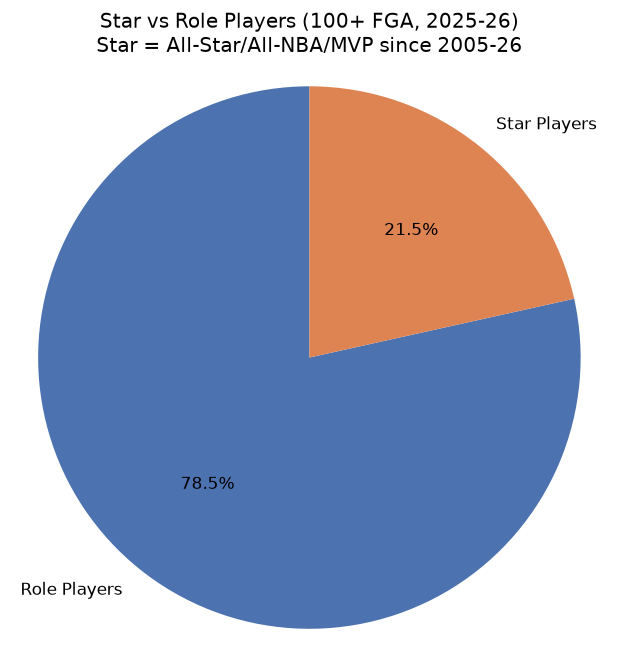

In [124]:
counts = season_df['is_star'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie([counts.get(False, 0), counts.get(True, 0)],
        labels=['Role Players', 'Star Players'],
        autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'], startangle=90)
plt.title('Star vs Role Players (100+ FGA, 2025-26)\nStar = All-Star/All-NBA/MVP since 2005-26')
plt.axis('equal')
plt.show()

### Chart 2 — Greats vs Stars vs Role
*The Great slice is exploded to show how thin it is — this is the sample-size
warning for the rest of the notebook.*

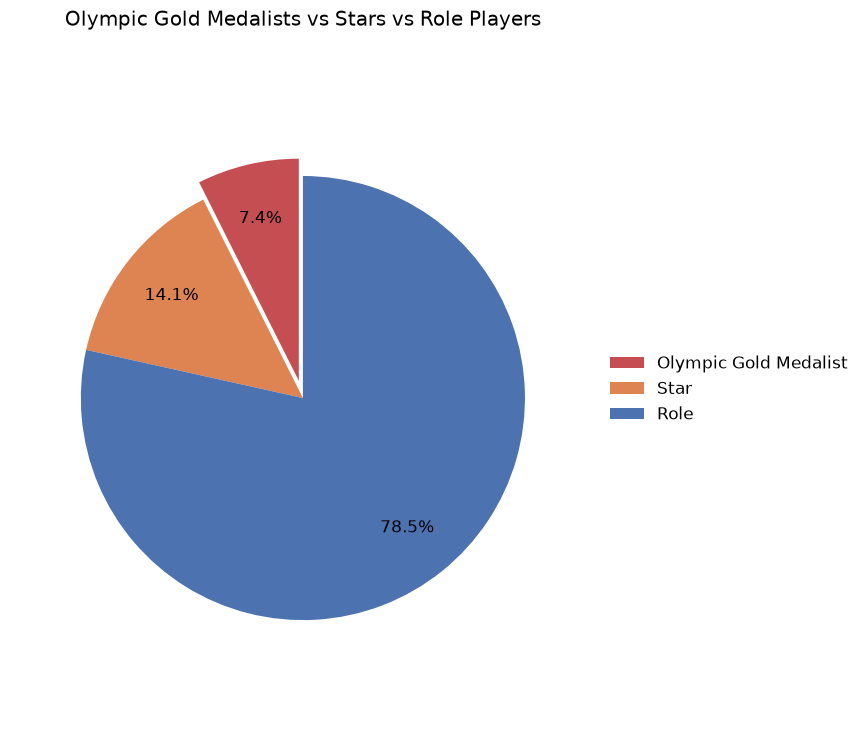

In [125]:
g = season_df['group'].value_counts().reindex(['Olympic Gold Medalist', 'Star', 'Role'])

fig, ax = plt.subplots(figsize=(8, 7))
wedges, texts, autotexts = ax.pie(
    g, autopct='%1.1f%%',
    colors=['#C44E52', '#DD8452', '#4C72B0'],
    startangle=90, explode=(0.08, 0, 0),
    pctdistance=0.75
)

ax.legend(wedges, g.index, loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
ax.set_title('Olympic Gold Medalists vs Stars vs Role Players')
plt.axis('equal')
plt.tight_layout()
plt.show()

## Season-Long Baseline
Establishing this first matters — without it, a clutch difference could just
mean stars are better players overall, not that pressure affects them differently.

### Chart 3 — Shooting & usage by tier
*Usage separates the tiers sharply; efficiency separates much less. That gap
between "how much they shoot" and "how well they shoot" is the thread the rest
of the notebook pulls on.*

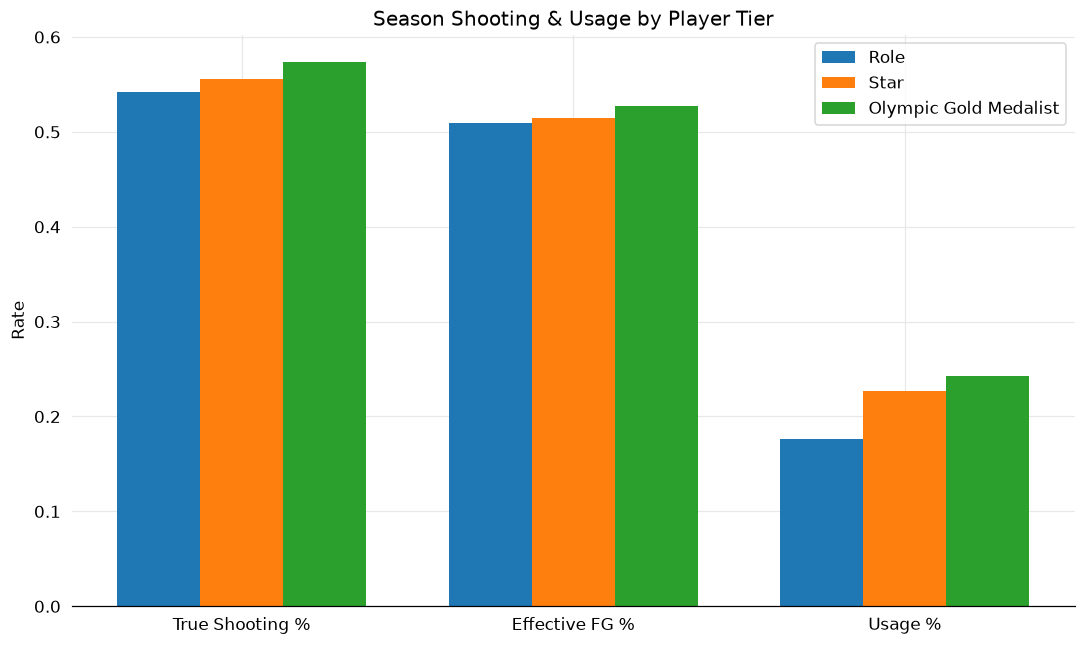

In [126]:
metrics = ['TS_PCT', 'EFG_PCT', 'USG_PCT']
grouped = season_df.groupby('group')[metrics].mean().reindex(['Role', 'Star', 'Olympic Gold Medalist'])

x = np.arange(len(metrics))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 6))
for i, grp in enumerate(grouped.index):
    ax.bar(x + i * width, grouped.loc[grp], width, label=grp)

ax.set_xticks(x + width)
ax.set_xticklabels(['True Shooting %', 'Effective FG %', 'Usage %'])
ax.set_ylabel('Rate')
ax.set_title('Season Shooting & Usage by Player Tier')
ax.legend()
plt.tight_layout()
plt.show()

### Chart 4 — Net Rating & PIE by tier
Plotted on separate axes — their scales differ by an order of magnitude.

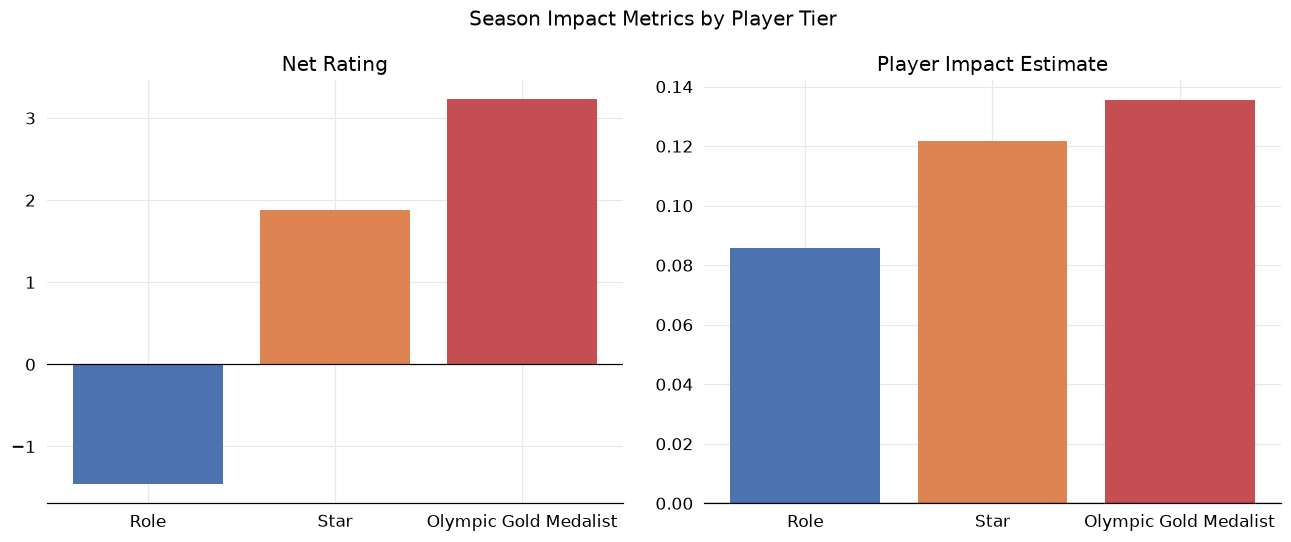

In [127]:
impact = ['NET_RATING', 'PIE']
gi = season_df.groupby('group')[impact].mean().reindex(['Role', 'Star', 'Olympic Gold Medalist'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, m, title in zip(axes, impact, ['Net Rating', 'Player Impact Estimate']):
    ax.bar(gi.index, gi[m], color=['#4C72B0', '#DD8452', '#C44E52'])
    ax.set_title(title)
    ax.axhline(0, color='black', linewidth=0.8)
plt.suptitle('Season Impact Metrics by Player Tier')
plt.tight_layout()
plt.show()

## Clutch vs. Season
> *Does clutch efficiency match season efficiency, and does the gap differ by tier?*

### Chart 5 — Season vs clutch efficiency, by tier
*Compare each tier against itself first — that within-tier gap is the pressure
effect. Then compare gaps across tiers.*

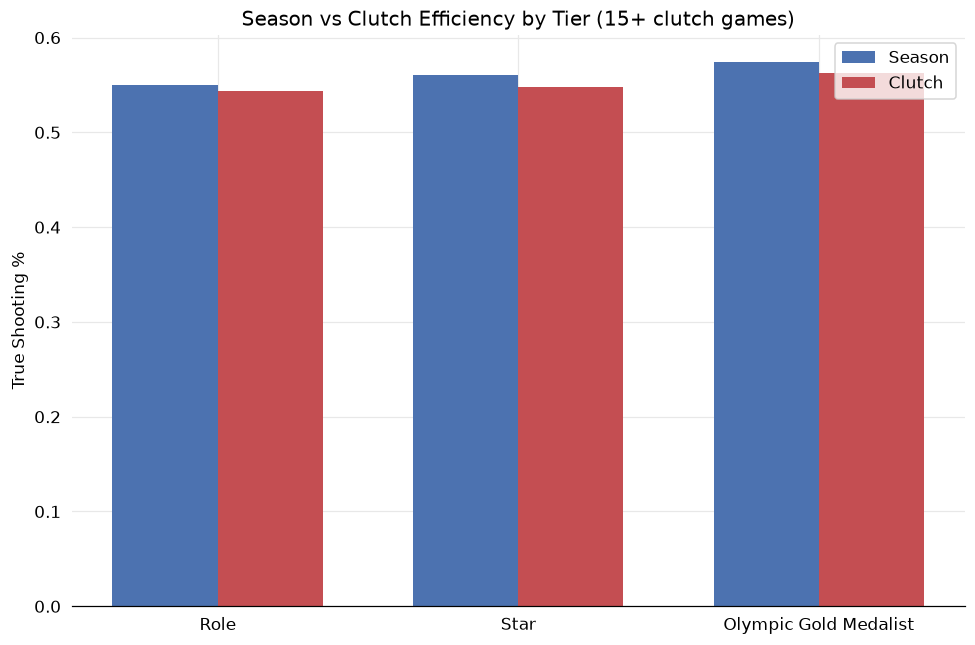

In [128]:
comp = df.groupby('group')[['TS_PCT_SEASON', 'TS_PCT_CLUTCH']].mean().reindex(['Role', 'Star', 'Olympic Gold Medalist'])

x = np.arange(len(comp))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(x - width/2, comp['TS_PCT_SEASON'], width, label='Season', color='#4C72B0')
ax.bar(x + width/2, comp['TS_PCT_CLUTCH'], width, label='Clutch', color='#C44E52')
ax.set_xticks(x)
ax.set_xticklabels(comp.index)
ax.set_ylabel('True Shooting %')
ax.set_title('Season vs Clutch Efficiency by Tier (15+ clutch games)')
ax.legend()
plt.tight_layout()
plt.show()

### Chart 6 — Player-level view of the same comparison
Dashed diagonal = no change. Above = better in clutch, below = worse.
*Averages can hide a split where half rise and half collapse. This shows
whether Chart 5's tier means reflect a real pattern.*

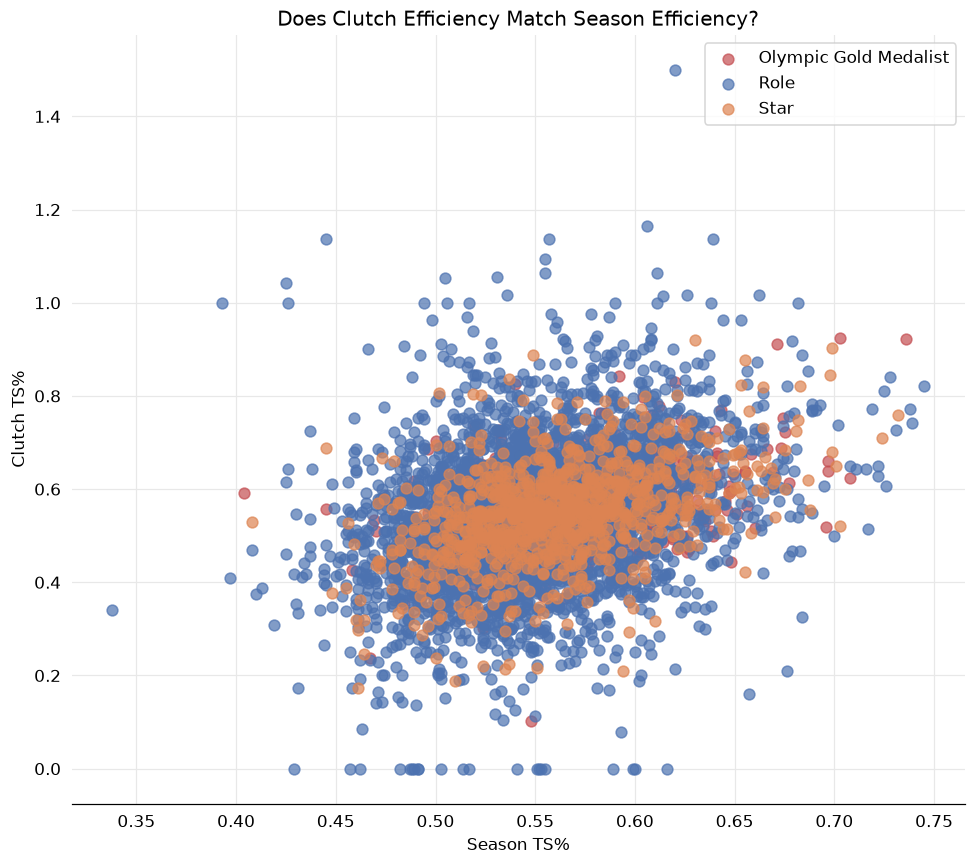

In [129]:
fig, ax = plt.subplots(figsize=(9, 8))
colors = {'Role': '#4C72B0', 'Star': '#DD8452', 'Olympic Gold Medalist': '#C44E52'}
for grp, sub in df.groupby('group'):
    ax.scatter(sub['TS_PCT_SEASON'], sub['TS_PCT_CLUTCH'],
               label=grp, alpha=0.7, s=50, color=colors[grp])

lims = [df[['TS_PCT_SEASON', 'TS_PCT_CLUTCH']].min().min(),
        df[['TS_PCT_SEASON', 'TS_PCT_CLUTCH']].max().max()]

ax.set_xlabel('Season TS%')
ax.set_ylabel('Clutch TS%')
ax.set_title('Does Clutch Efficiency Match Season Efficiency?')
ax.legend()
plt.tight_layout()
plt.show()

### Chart 7 — Distribution of the pressure effect
*The width matters more than the position. Heavy overlap across tiers means
tier membership explains little of the variation.*

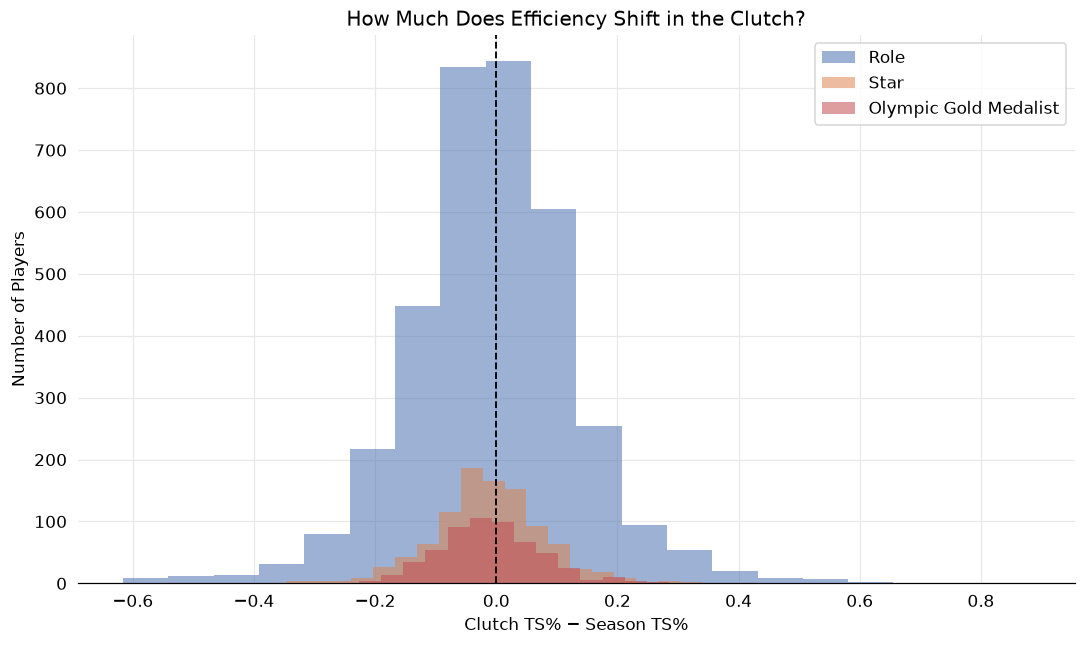

In [130]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = {'Role': '#4C72B0', 'Star': '#DD8452', 'Olympic Gold Medalist': '#C44E52'}

for grp in ['Role', 'Star', 'Olympic Gold Medalist']:
    sub = df[df['group'] == grp]
    ax.hist(sub['TS_DELTA'], bins=20, alpha=0.55, label=grp, color=colors[grp])

ax.axvline(0, color='black', linestyle='--', linewidth=1.2)
ax.set_xlabel('Clutch TS% − Season TS%')
ax.set_ylabel('Number of Players')
ax.set_title('How Much Does Efficiency Shift in the Clutch?')
ax.legend()
plt.tight_layout()
plt.show()

### Chart 8 — Do stars absorb more clutch usage?
*The mechanism behind the thesis: offenses funnel late-game possessions to
their known player. If usage jumps for stars while efficiency (Chart 5) stays
flat, those extra shots are allocated on reputation, not demonstrated ability.*

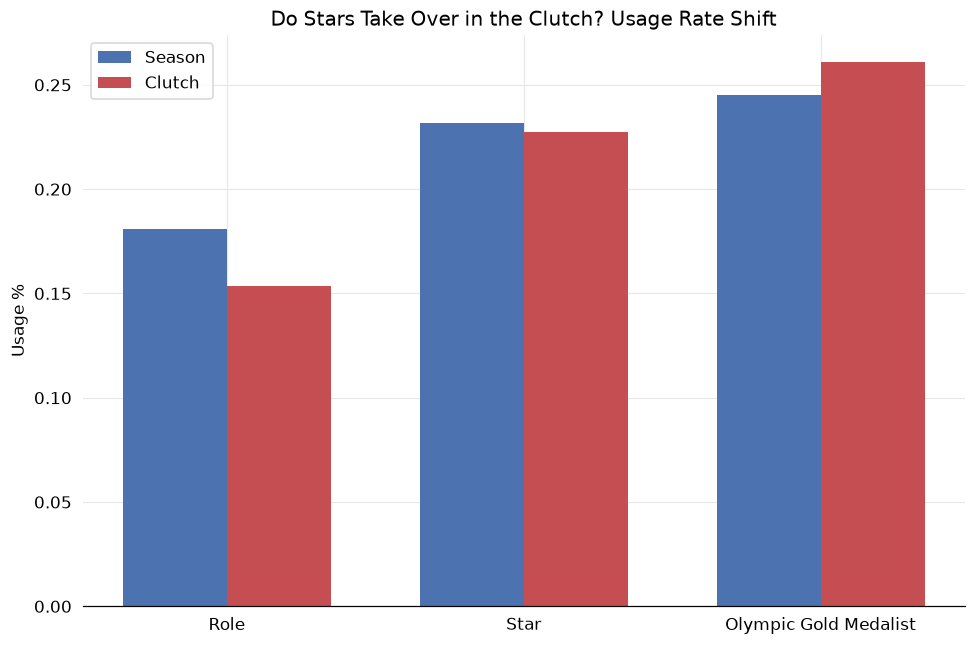

In [131]:
usg = df.groupby('group')[['USG_PCT_SEASON', 'USG_PCT_CLUTCH']].mean().reindex(['Role', 'Star', 'Olympic Gold Medalist'])

x = np.arange(len(usg))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(x - width/2, usg['USG_PCT_SEASON'], width, label='Season', color='#4C72B0')
ax.bar(x + width/2, usg['USG_PCT_CLUTCH'], width, label='Clutch', color='#C44E52')
ax.set_xticks(x)
ax.set_xticklabels(usg.index)
ax.set_ylabel('Usage %')
ax.set_title('Do Stars Take Over in the Clutch? Usage Rate Shift')
ax.legend()
plt.tight_layout()
plt.show()

### Chart 9 — Biggest clutch risers
Looking at the best clutch performers in the league.

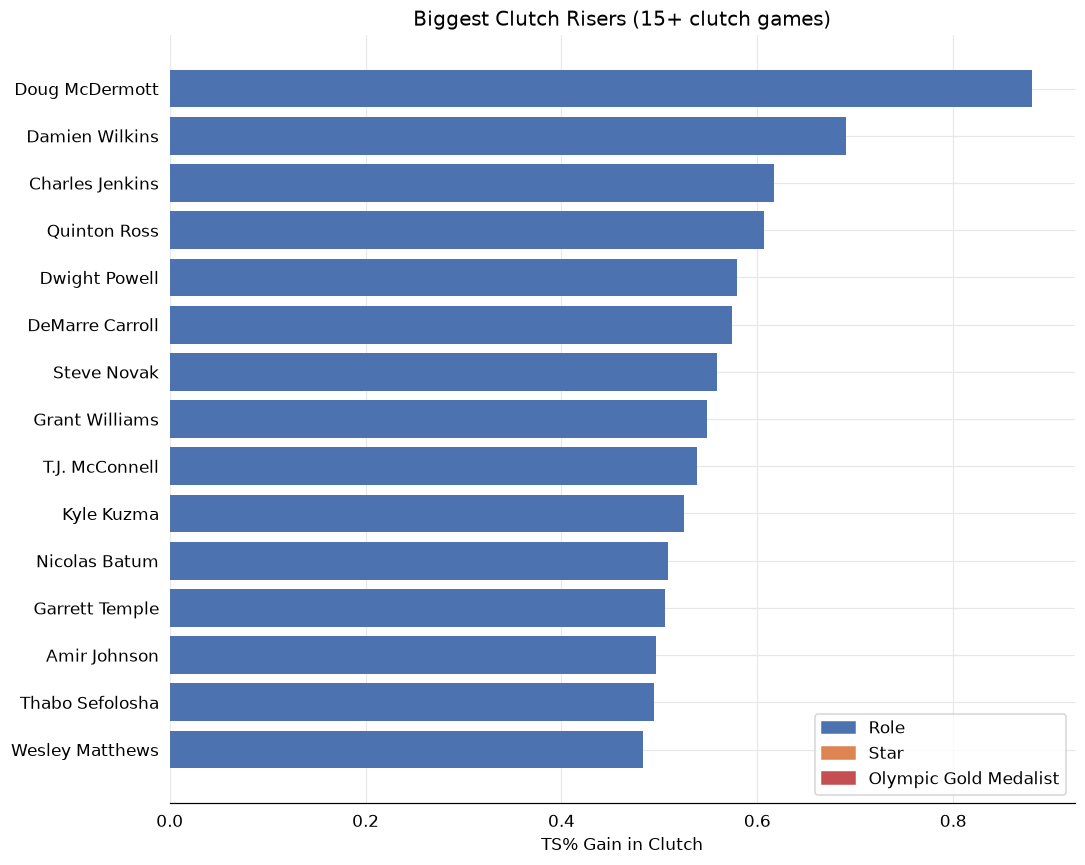

In [132]:
risers = df.nlargest(15, 'TS_DELTA')[['PLAYER_NAME', 'TS_DELTA', 'group']]

fig, ax = plt.subplots(figsize=(10, 8))
bar_colors = [colors[g] for g in risers['group']]
ax.barh(risers['PLAYER_NAME'], risers['TS_DELTA'], color=bar_colors)
ax.invert_yaxis()
ax.set_xlabel('TS% Gain in Clutch')
ax.set_title('Biggest Clutch Risers (15+ clutch games)')

handles = [plt.Rectangle((0,0),1,1, color=c) for c in colors.values()]
ax.legend(handles, colors.keys())
plt.tight_layout()
plt.show()

### Chart 9b — Biggest risers, one tier at a time
The chart above ranks the top 15 clutch risers across the *entire* league —
and because Role players vastly outnumber Star and Olympic Gold Medalist
players in this dataset, that ranking is dominated by population size, not
necessarily by anything tier-specific. This version instead takes the top 5
riser from *within* each tier separately, guaranteeing all three tiers are
represented and letting their best cases be compared directly.

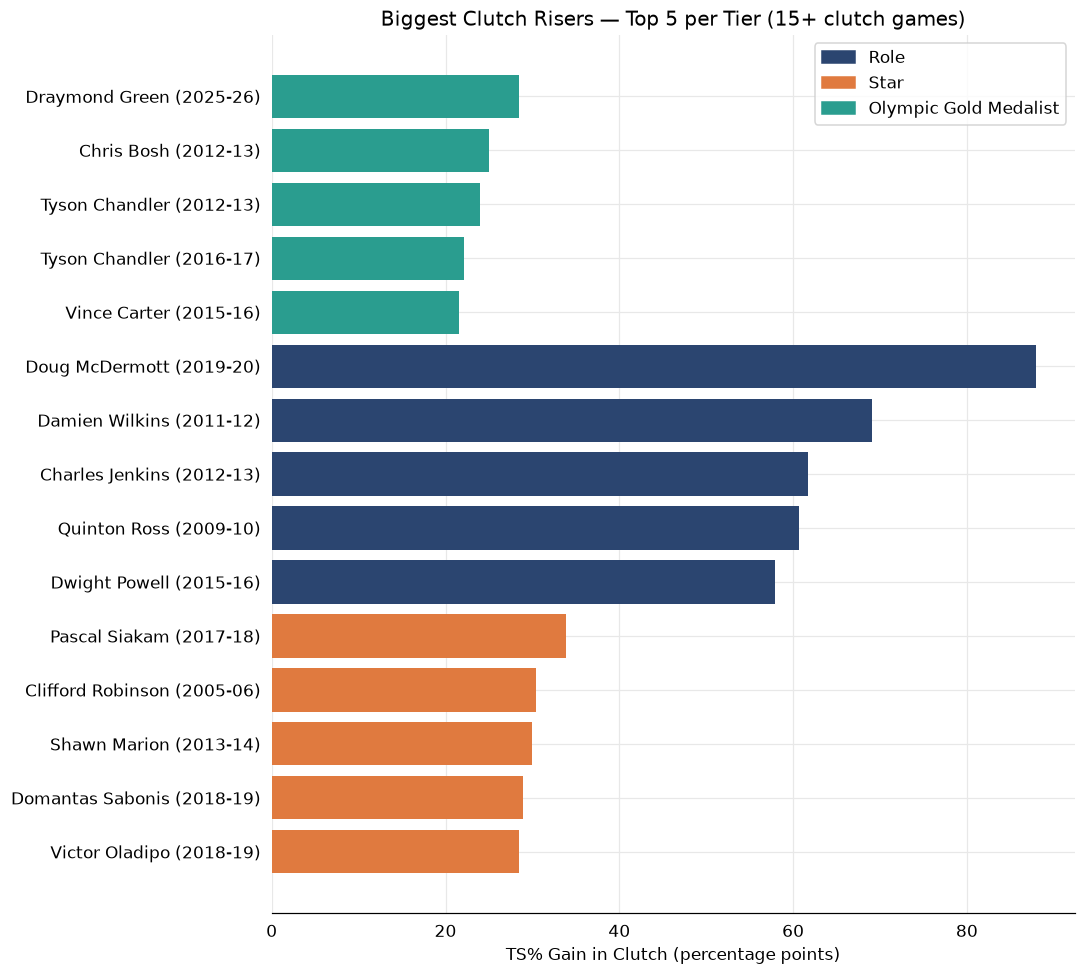

In [133]:
top_n_per_tier = 5

risers_per_tier = (
    df.sort_values('TS_DELTA', ascending=False)
      .groupby('group')
      .head(top_n_per_tier)
      .sort_values(['group', 'TS_DELTA'], ascending=[True, False])
)
risers_per_tier['label'] = risers_per_tier['PLAYER_NAME'] + ' (' + risers_per_tier['SEASON'] + ')'

fig, ax = plt.subplots(figsize=(10, 9))
bar_colors = [TIER_C[g] for g in risers_per_tier['group']]
ax.barh(risers_per_tier['label'], risers_per_tier['TS_DELTA'] * 100, color=bar_colors)
ax.invert_yaxis()
ax.set_xlabel('TS% Gain in Clutch (percentage points)')
ax.set_title(f'Biggest Clutch Risers — Top {top_n_per_tier} per Tier (15+ clutch games)')

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in TIER_C.values()]
ax.legend(handles, TIER_C.keys())
plt.tight_layout()
plt.show()

In [134]:
print(risers_per_tier[['group', 'label', 'TS_DELTA']].to_string(index=False))

                group                       label  TS_DELTA
Olympic Gold Medalist    Draymond Green (2025-26)     0.285
Olympic Gold Medalist        Chris Bosh (2012-13)     0.250
Olympic Gold Medalist    Tyson Chandler (2012-13)     0.240
Olympic Gold Medalist    Tyson Chandler (2016-17)     0.221
Olympic Gold Medalist      Vince Carter (2015-16)     0.215
                 Role    Doug McDermott (2019-20)     0.880
                 Role    Damien Wilkins (2011-12)     0.691
                 Role   Charles Jenkins (2012-13)     0.617
                 Role      Quinton Ross (2009-10)     0.607
                 Role     Dwight Powell (2015-16)     0.579
                 Star     Pascal Siakam (2017-18)     0.339
                 Star Clifford Robinson (2005-06)     0.304
                 Star      Shawn Marion (2013-14)     0.300
                 Star  Domantas Sabonis (2018-19)     0.289
                 Star    Victor Oladipo (2018-19)     0.285


### Chart 10 — Biggest clutch fallers
*Present with Chart 9. If stars are overrepresented among fallers relative to
their population share, that's the strongest single piece of evidence for the
thesis — though these are distribution extremes, exactly where small samples
look biggest.*

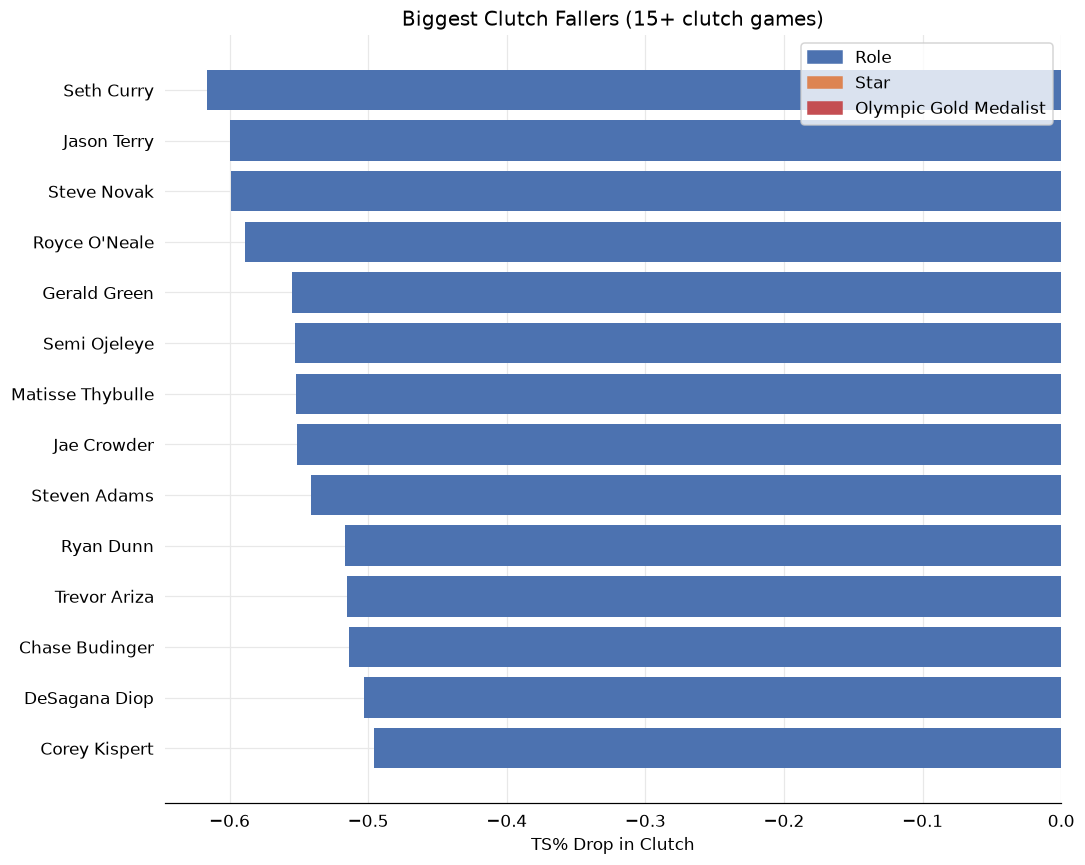

In [135]:
fallers = df.nsmallest(15, 'TS_DELTA')[['PLAYER_NAME', 'TS_DELTA', 'group']]

fig, ax = plt.subplots(figsize=(10, 8))
bar_colors = [colors[g] for g in fallers['group']]
ax.barh(fallers['PLAYER_NAME'], fallers['TS_DELTA'], color=bar_colors)
ax.invert_yaxis()
ax.set_xlabel('TS% Drop in Clutch')
ax.set_title('Biggest Clutch Fallers (15+ clutch games)')

handles = [plt.Rectangle((0,0),1,1, color=c) for c in colors.values()]
ax.legend(handles, colors.keys())
plt.tight_layout()
plt.show()

### Chart 10b — Biggest fallers, one tier at a time
Same fix as the risers version above — top 5 faller within each tier, instead
of top 15 across the whole population.

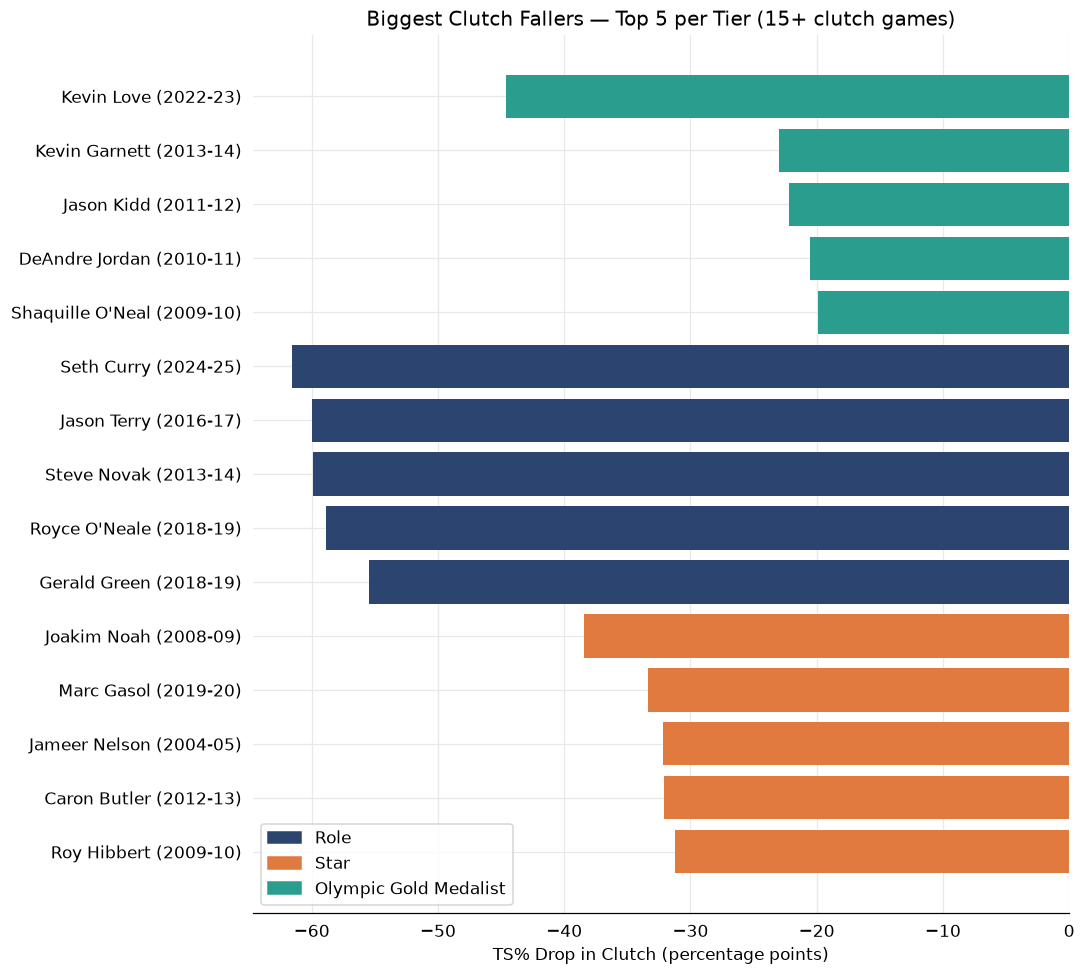

In [136]:
fallers_per_tier = (
    df.sort_values('TS_DELTA', ascending=True)
      .groupby('group')
      .head(top_n_per_tier)
      .sort_values(['group', 'TS_DELTA'], ascending=[True, True])
)
fallers_per_tier['label'] = fallers_per_tier['PLAYER_NAME'] + ' (' + fallers_per_tier['SEASON'] + ')'

fig, ax = plt.subplots(figsize=(10, 9))
bar_colors = [TIER_C[g] for g in fallers_per_tier['group']]
ax.barh(fallers_per_tier['label'], fallers_per_tier['TS_DELTA'] * 100, color=bar_colors)
ax.invert_yaxis()
ax.set_xlabel('TS% Drop in Clutch (percentage points)')
ax.set_title(f'Biggest Clutch Fallers — Top {top_n_per_tier} per Tier (15+ clutch games)')

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in TIER_C.values()]
ax.legend(handles, TIER_C.keys())
plt.tight_layout()
plt.show()

### Chart 11 — Consistency under pressure
*A tier can average zero change while containing both players who reliably
rise and players who reliably collapse — a taller box means less predictable
clutch performance.*

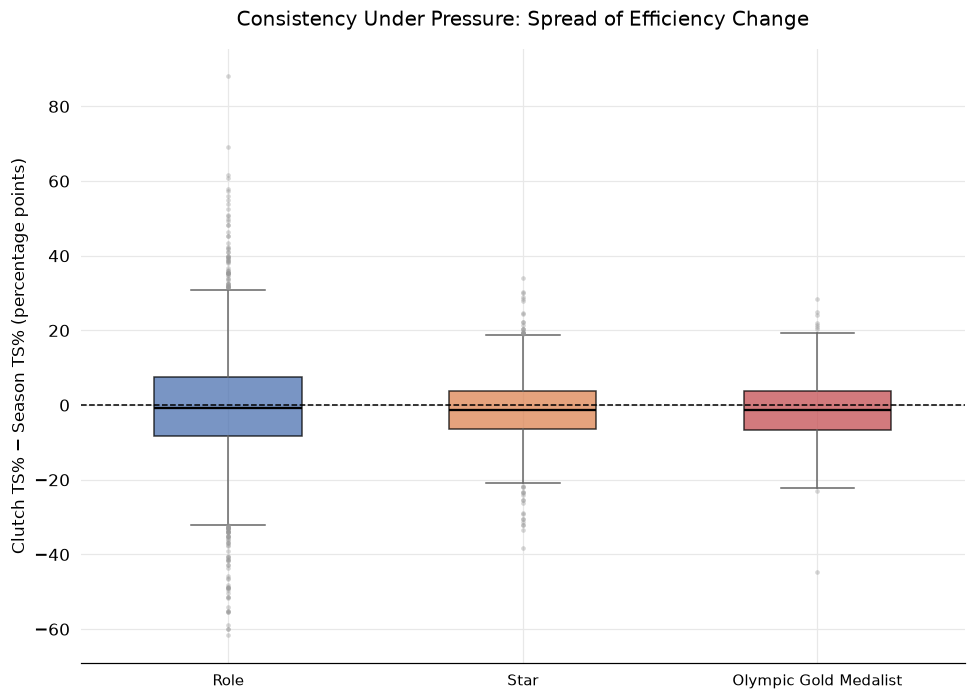

In [137]:
groups_order = ['Role', 'Star', 'Olympic Gold Medalist']
tier_colors = {'Role': '#4C72B0', 'Star': '#DD8452', 'Olympic Gold Medalist': '#C44E52'}
data = [df.loc[df['group'] == g, 'TS_DELTA'].dropna() * 100 for g in groups_order]

fig, ax = plt.subplots(figsize=(9, 6.5))

bp = ax.boxplot(
    data, tick_labels=groups_order, patch_artist=True,
    widths=0.5,
    flierprops=dict(marker='o', markersize=3, markerfacecolor='#999',
                     markeredgecolor='none', alpha=0.4),
    medianprops=dict(color='black', linewidth=1.5),
    boxprops=dict(linewidth=1),
    whiskerprops=dict(color='#666'),
    capprops=dict(color='#666'),
)

for patch, g in zip(bp['boxes'], groups_order):
    patch.set_facecolor(tier_colors[g])
    patch.set_alpha(0.75)

ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_ylabel('Clutch TS% − Season TS% (percentage points)')
ax.set_title('Consistency Under Pressure: Spread of Efficiency Change', pad=15)

ax.set_xticklabels(groups_order, fontsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='#e8e8e8', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Home vs. Road
> *Do home/road splits show a measurable clutch difference?*

### Fetch location-split clutch data
Same clutch definition, filtered by `location_nullable`. Wrapped in a function
so the six clutch parameters live in one place.

In [138]:
def fetch_all_seasons_clutch_location(location, cache_path):
    if os.path.exists(cache_path):
        out_df = pd.read_parquet(cache_path)
        print(f"Loaded {len(out_df)} rows from cache")
        return out_df

    frames = []
    for i, season in enumerate(seasons, start=1):
        clutch = leaguedashplayerclutch.LeagueDashPlayerClutch(
            season=season,
            season_type_all_star=reg_season,
            measure_type_detailed_defense=advanced_stats,
            clutch_time='Last 5 Minutes',
            ahead_behind='Ahead or Behind',
            point_diff=5,
            location_nullable=location
        )
        season_loc_df = clutch.get_data_frames()[0]
        season_loc_df['SEASON'] = season
        frames.append(season_loc_df)
        print(f"{i}/{len(seasons)} seasons fetched ({season}, {location})")
        time.sleep(0.6)

    out_df = pd.concat(frames, ignore_index=True)
    out_df.to_parquet(cache_path)
    return out_df

home_clutch_df = fetch_all_seasons_clutch_location('Home', 'all_seasons_clutch_home.parquet')
road_clutch_df = fetch_all_seasons_clutch_location('Road', 'all_seasons_clutch_road.parquet')

print(len(home_clutch_df), len(road_clutch_df))

Loaded 9020 rows from cache
Loaded 9094 rows from cache
9020 9094


### Merge splits and apply a sample floor
Self-join puts each player's home/road numbers on one row. The 8-game floor in
each location matters — splitting an already-small clutch sample by venue
halves it again. Check the printed count before trusting Charts 12–14.

In [139]:
hr_cols = ['PLAYER_ID', 'SEASON', 'GP', 'TS_PCT', 'NET_RATING', 'USG_PCT']

hr = (home_clutch_df[hr_cols]
      .merge(road_clutch_df[hr_cols], on=['PLAYER_ID', 'SEASON'], suffixes=('_HOME', '_ROAD')))

hr = hr[(hr['GP_HOME'] >= 8) & (hr['GP_ROAD'] >= 8)].copy()
hr['TS_HOME_ROAD_GAP'] = hr['TS_PCT_HOME'] - hr['TS_PCT_ROAD']

hr = hr.merge(df[['PLAYER_ID', 'SEASON', 'PLAYER_NAME', 'group']], on=['PLAYER_ID', 'SEASON'], how='inner')
print(f"{len(hr)} player-seasons with 8+ clutch games home and road")
hr['group'].value_counts()

4382 player-seasons with 8+ clutch games home and road


group
Role                     2930
Star                      922
Olympic Gold Medalist     530
Name: count, dtype: int64

### Chart 12 — Clutch efficiency, home vs road
Sample sizes are printed on the x-axis labels — do this on every tier chart
from here on.

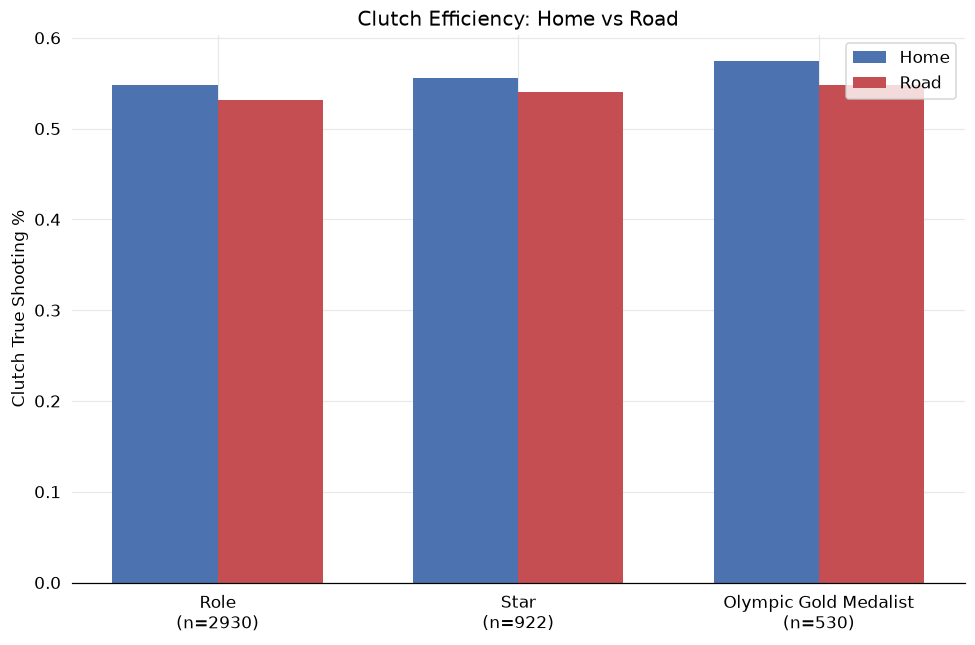

In [140]:
hr_ts = hr.groupby('group')[['TS_PCT_HOME', 'TS_PCT_ROAD']].mean().reindex(['Role', 'Star', 'Olympic Gold Medalist'])

x = np.arange(len(hr_ts))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(x - width/2, hr_ts['TS_PCT_HOME'], width, label='Home', color='#4C72B0')
ax.bar(x + width/2, hr_ts['TS_PCT_ROAD'], width, label='Road', color='#C44E52')
ax.set_xticks(x)
ax.set_xticklabels([f'{t}\n(n={c})' for t, c in zip(hr_ts.index, hr['group'].value_counts().reindex(hr_ts.index))])
ax.set_ylabel('Clutch True Shooting %')
ax.set_title('Clutch Efficiency: Home vs Road')
ax.legend()
plt.tight_layout()
plt.show()

### Chart 13 — Home vs road, player by player
*If the cloud sits symmetrically around the diagonal, home court doesn't move
clutch shooting — a clean negative answer to sub-question 3, worth stating
plainly rather than hunting for a pattern that isn't there.*

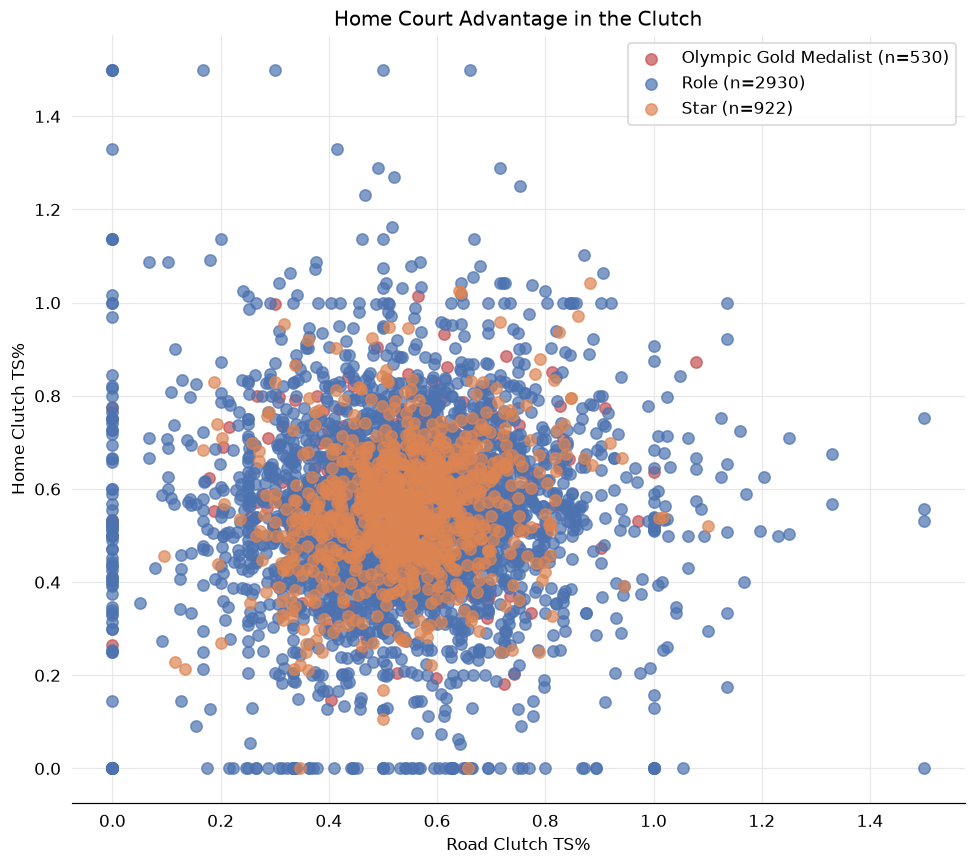

In [141]:
fig, ax = plt.subplots(figsize=(9, 8))
c3 = {'Role': '#4C72B0', 'Star': '#DD8452', 'Olympic Gold Medalist': '#C44E52'}

for tier, sub in hr.groupby('group'):
    ax.scatter(sub['TS_PCT_ROAD'], sub['TS_PCT_HOME'],
               label=f'{tier} (n={len(sub)})', alpha=0.7, s=55, color=c3[tier])

lims = [hr[['TS_PCT_HOME', 'TS_PCT_ROAD']].min().min(),
        hr[['TS_PCT_HOME', 'TS_PCT_ROAD']].max().max()]

ax.set_xlabel('Road Clutch TS%')
ax.set_ylabel('Home Clutch TS%')
ax.set_title('Home Court Advantage in the Clutch')
ax.legend()
plt.tight_layout()
plt.show()

### Chart 14 — Home court swing in clutch net rating
**Interpret cautiously** — clutch net ratings swing ±30 on small samples;
taking the difference of two noisy numbers compounds that. Check
`hr.groupby('group')['NET_GAP'].std()` alongside this chart, across all
three tiers.

## Volume vs. Efficiency
> *Do stars absorb more clutch usage, and does it cost them efficiency?*

### Chart 15 — Season-long volume vs efficiency tradeoff
*Stars should cluster right, at high usage. The question is whether they hold
efficiency there — this sets the baseline pattern before pressure is added.*

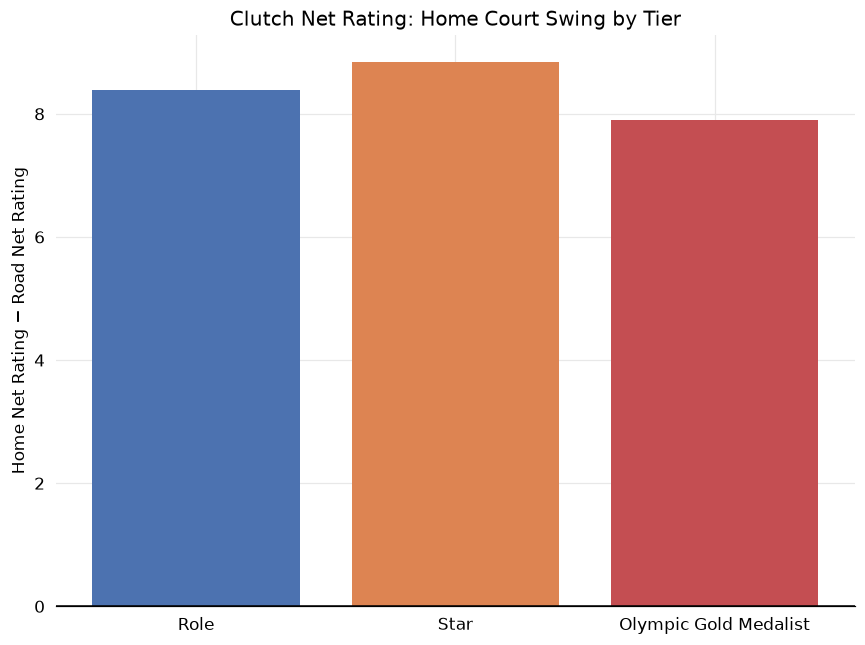

In [142]:
hr['NET_GAP'] = hr['NET_RATING_HOME'] - hr['NET_RATING_ROAD']
gap = hr.groupby('group')['NET_GAP'].mean().reindex(['Role', 'Star', 'Olympic Gold Medalist'])

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(gap.index, gap, color=['#4C72B0', '#DD8452', '#C44E52'])
ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('Home Net Rating − Road Net Rating')
ax.set_title('Clutch Net Rating: Home Court Swing by Tier')
plt.tight_layout()
plt.show()

### Chart 16 — Does clutch volume cost efficiency?
**The sharpest single test of the thesis.** *A downward slope — higher clutch
usage, bigger efficiency drop — is direct evidence that giving the star the
ball late is measurably costly.*

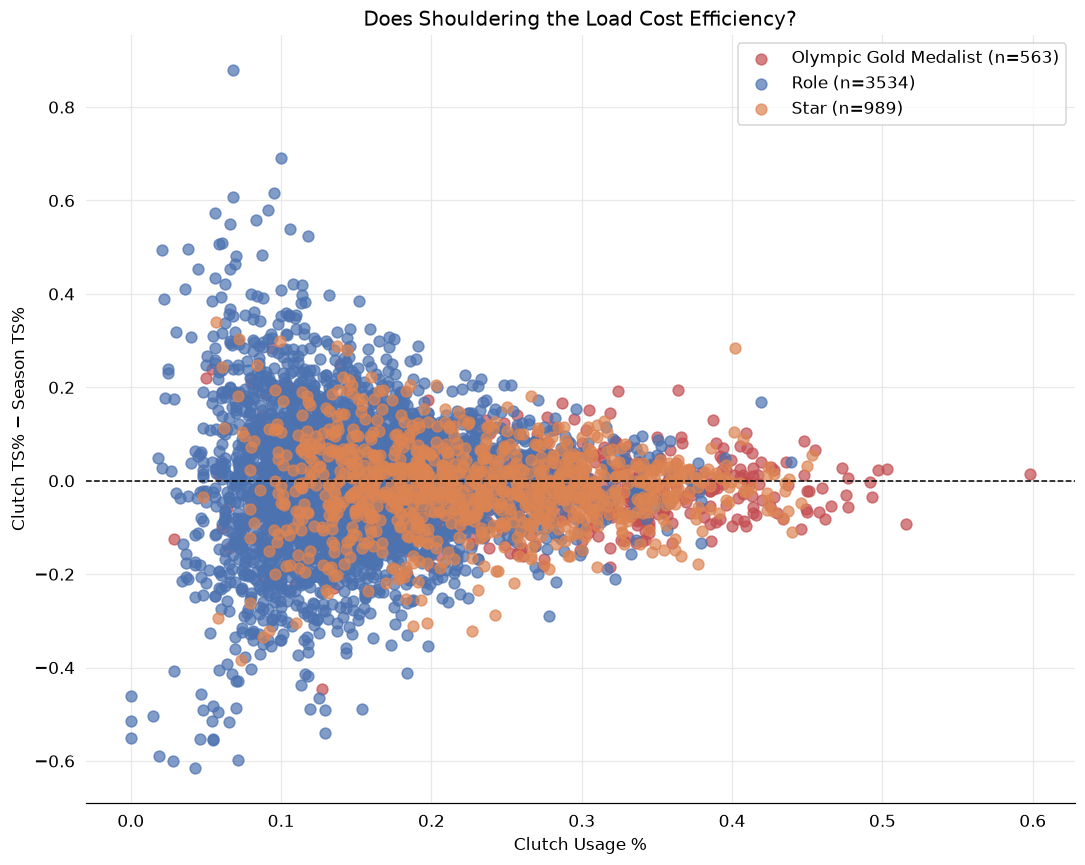

In [143]:
fig, ax = plt.subplots(figsize=(10, 8))
for grp, sub in df.groupby('group'):
    ax.scatter(sub['USG_PCT_CLUTCH'], sub['TS_DELTA'],
               label=f'{grp} (n={len(sub)})', alpha=0.7, s=50, color=colors[grp])

ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Clutch Usage %')
ax.set_ylabel('Clutch TS% − Season TS%')
ax.set_title('Does Shouldering the Load Cost Efficiency?')
ax.legend()
plt.tight_layout()
plt.show()

## Trend Analysis
### Chart 17 — Does season efficiency predict clutch efficiency?
Same quintile logic as before, now computed across 22 seasons' worth of
player-seasons (2004-05 through 2025-26) rather than a single year. `qcut`
bins by rank, so every quintile has an even count regardless of scale.

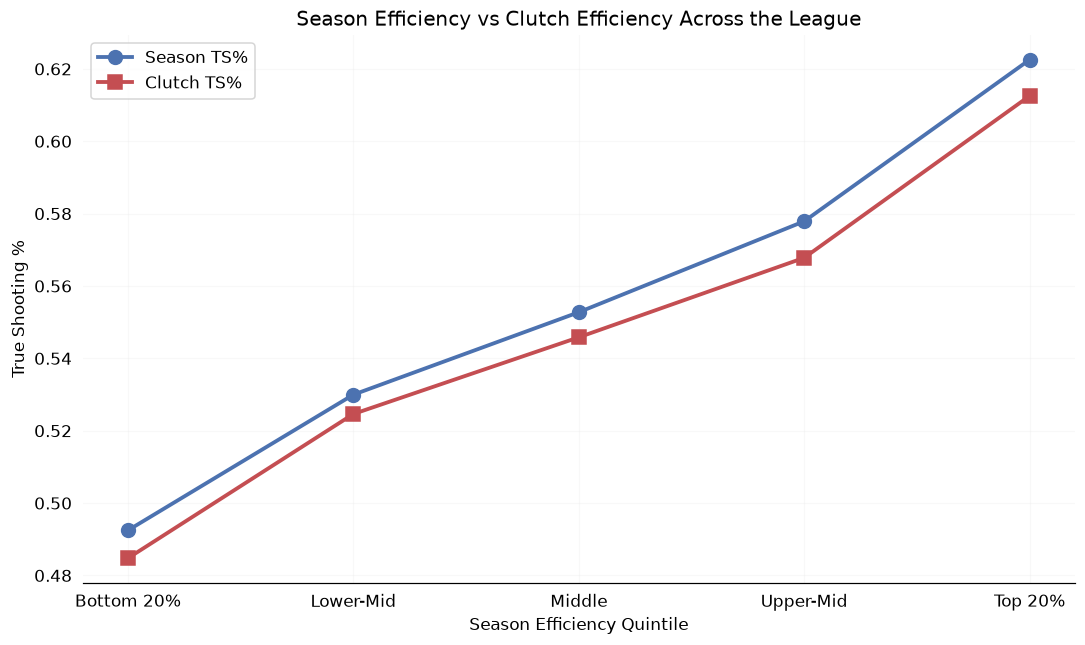

ts_quintile
Bottom 20%    1018
Lower-Mid     1039
Middle        1015
Upper-Mid     1020
Top 20%        994
dtype: int64


In [144]:
df['ts_quintile'] = pd.qcut(
    df['TS_PCT_SEASON'], q=5,
    labels=['Bottom 20%', 'Lower-Mid', 'Middle', 'Upper-Mid', 'Top 20%']
)

trend = df.groupby('ts_quintile', observed=True)[['TS_PCT_SEASON', 'TS_PCT_CLUTCH']].mean()
sizes = df.groupby('ts_quintile', observed=True).size()

fig, ax = plt.subplots(figsize=(10, 6))
x = [str(i) for i in trend.index]

ax.plot(x, trend['TS_PCT_SEASON'], marker='o', linewidth=2.5, markersize=9,
        label='Season TS%', color='#4C72B0')
ax.plot(x, trend['TS_PCT_CLUTCH'], marker='s', linewidth=2.5, markersize=9,
        label='Clutch TS%', color='#C44E52')

ax.set_xlabel('Season Efficiency Quintile')
ax.set_ylabel('True Shooting %')
ax.set_title('Season Efficiency vs Clutch Efficiency Across the League')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(sizes)

### Chart 18 — Same comparison, split by tier
*Controls for the obvious confound — stars are better players on average, so a
raw comparison flatters them. This compares stars and role players at matched
efficiency levels. If the star line sits below role at the same efficiency
level, stars get less out of clutch situations despite taking more shots.*

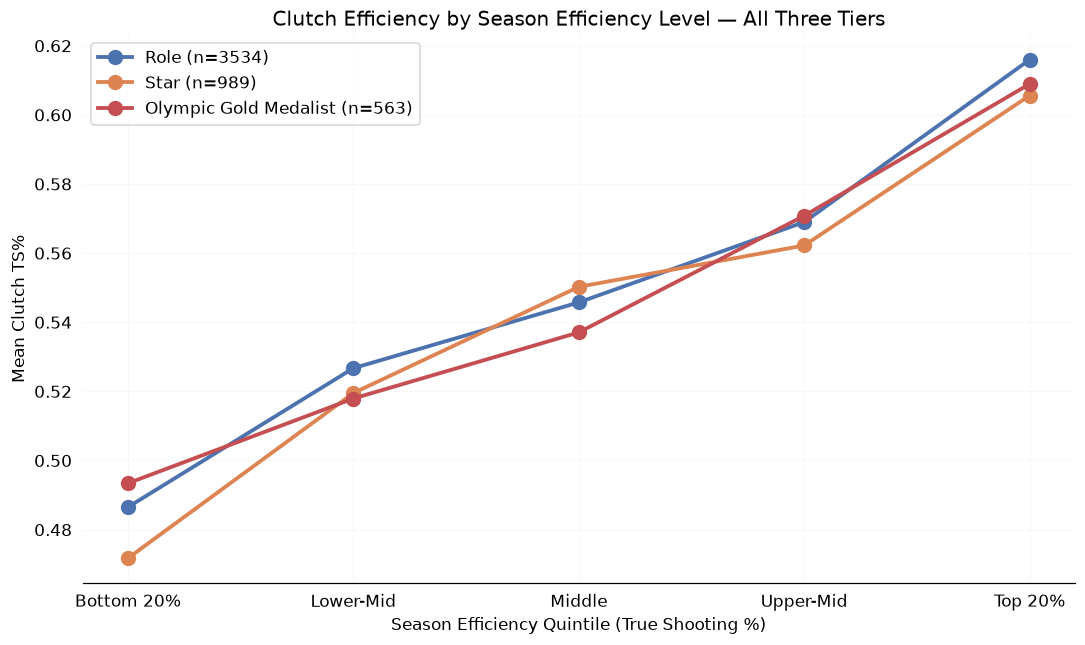

group        Olympic Gold Medalist  Role  Star
ts_quintile                                   
Bottom 20%                      42   836   140
Lower-Mid                       81   755   203
Middle                         100   705   210
Upper-Mid                      169   626   225
Top 20%                        171   612   211


In [145]:
df['ts_quintile'] = pd.qcut(
    df['TS_PCT_SEASON'], q=5,
    labels=['Bottom 20%', 'Lower-Mid', 'Middle', 'Upper-Mid', 'Top 20%']
)

qt = df.groupby(['ts_quintile', 'group'], observed=True)['TS_PCT_CLUTCH'].mean().unstack()
qc = df.groupby(['ts_quintile', 'group'], observed=True).size().unstack(fill_value=0)
qt = qt.where(qc >= 3)

c3 = {'Role': '#4C72B0', 'Star': '#DD8452', 'Olympic Gold Medalist': '#C44E52'}

fig, ax = plt.subplots(figsize=(10, 6))
for tier in ['Role', 'Star', 'Olympic Gold Medalist']:
    if tier in qt.columns:
        s = qt[tier].dropna()
        if len(s) >= 2:
            ax.plot([str(i) for i in s.index], s.values, marker='o',
                    linewidth=2.5, markersize=9,
                    label=f'{tier} (n={qc[tier].sum()})', color=c3[tier])

ax.set_xlabel('Season Efficiency Quintile (True Shooting %)')
ax.set_ylabel('Mean Clutch TS%')
ax.set_title('Clutch Efficiency by Season Efficiency Level — All Three Tiers')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(qc)

### Chart 19 — Clutch efficiency by clutch shot volume
*Isolates volume from talent. If both lines decline as volume rises, the
effect is about difficulty of high-volume late shots generally, not about who's taking them.*

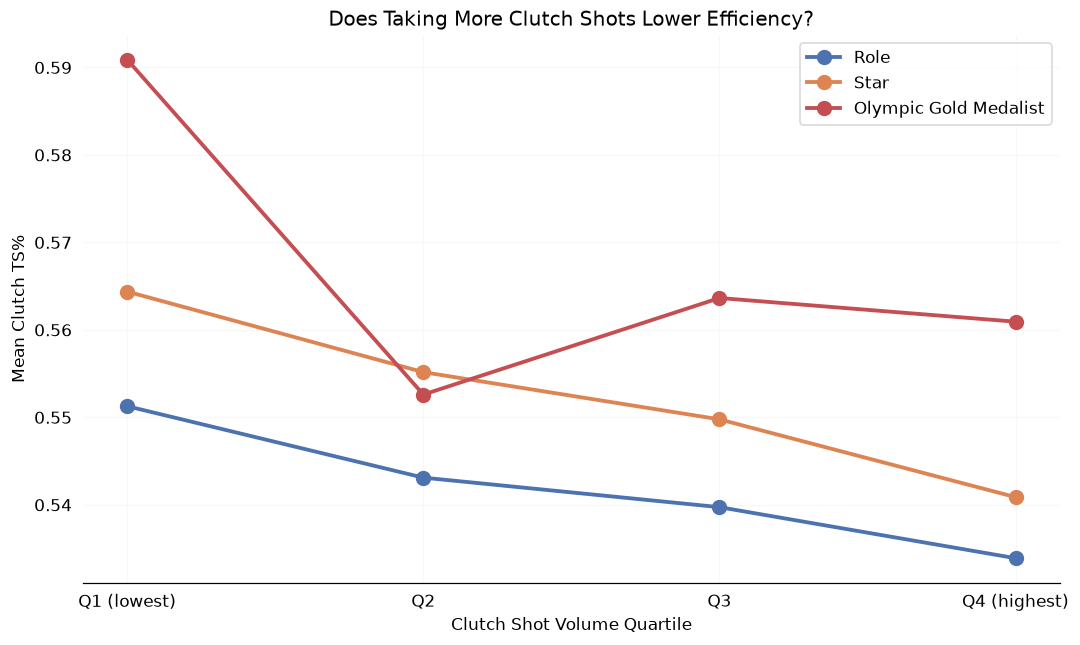

In [146]:
df['fga_quartile'] = pd.qcut(df['FGA_CLUTCH'], q=4,
                             labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)'])

wt = df.groupby(['fga_quartile', 'group'], observed=True)['TS_PCT_CLUTCH'].mean().unstack()
wc = df.groupby(['fga_quartile', 'group'], observed=True).size().unstack(fill_value=0)
wt = wt.where(wc >= 3)

fig, ax = plt.subplots(figsize=(10, 6))
for tier in ['Role', 'Star', 'Olympic Gold Medalist']:
    if tier in wt.columns:
        s = wt[tier].dropna()
        if len(s) >= 2:
            ax.plot([str(i) for i in s.index], s.values, marker='o',
                    linewidth=2.5, markersize=9, label=tier, color=c3[tier])

ax.set_xlabel('Clutch Shot Volume Quartile')
ax.set_ylabel('Mean Clutch TS%')
ax.set_title('Does Taking More Clutch Shots Lower Efficiency?')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [147]:
print(wc)

group         Olympic Gold Medalist  Role  Star
fga_quartile                                   
Q1 (lowest)                      51  1212    73
Q2                               75  1013   154
Q3                               97   872   279
Q4 (highest)                    340   437   483


### Chart 20 — Usage shift by tier: the closing argument
Solid = season usage, dashed = clutch usage, same color = same tier.
*The vertical gap within each color pair is how much that tier's workload
grows under pressure — if star dashed jumps well above star solid while role
stays flat, offenses are demonstrably concentrating clutch touches on stars.*

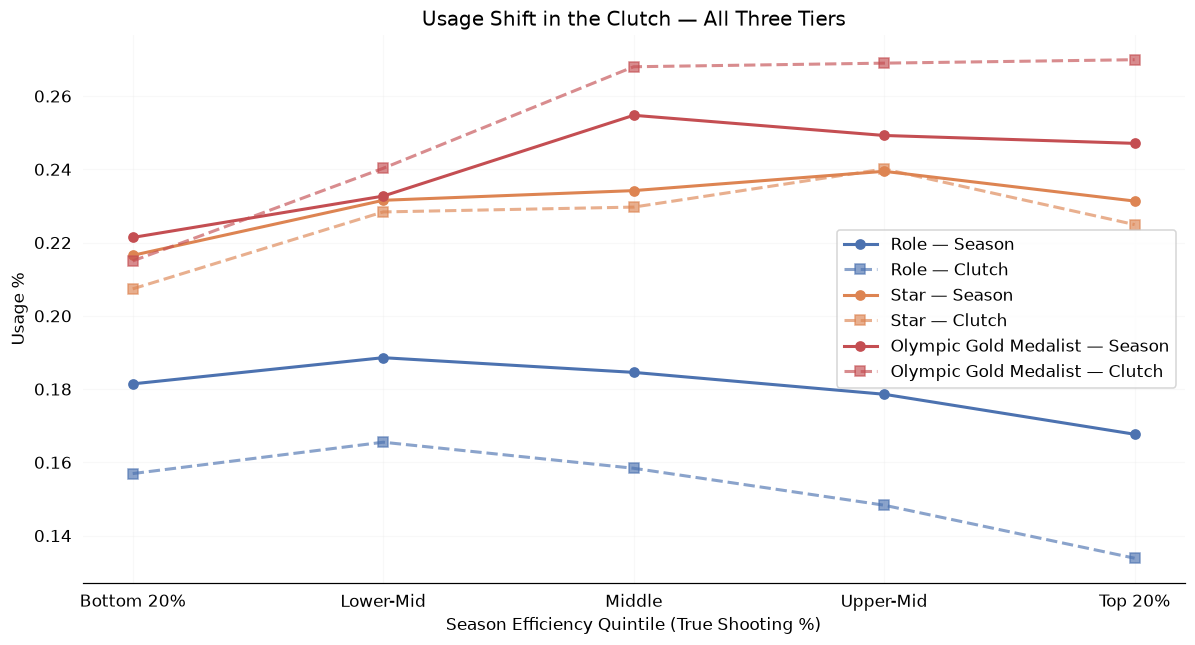

In [148]:
uq = df.groupby(['ts_quintile', 'group'], observed=True)[['USG_PCT_SEASON', 'USG_PCT_CLUTCH']].mean()

fig, ax = plt.subplots(figsize=(11, 6))
for tier in ['Role', 'Star', 'Olympic Gold Medalist']:
    sub = uq.xs(tier, level='group')
    x = [str(i) for i in sub.index]
    ax.plot(x, sub['USG_PCT_SEASON'], marker='o', linewidth=2,
            label=f'{tier} — Season', color=c3[tier])
    ax.plot(x, sub['USG_PCT_CLUTCH'], marker='s', linewidth=2, linestyle='--',
            label=f'{tier} — Clutch', color=c3[tier], alpha=0.65)

ax.set_xlabel('Season Efficiency Quintile (True Shooting %)')
ax.set_ylabel('Usage %')
ax.set_title('Usage Shift in the Clutch — All Three Tiers')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [149]:
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'grid.color': '#E8E8E8',
    'grid.linewidth': 0.8,
    'xtick.bottom': False,
    'ytick.left': False,
})

NAVY  = '#2B4570'   # Role
ORANGE= '#E07A3F'   # Star
TEAL  = '#2A9D8F'   # Great
MUTED = '#C9CCD1'   # de-emphasized

TIER_C = {'Role': NAVY, 'Star': ORANGE, 'Olympic Gold Medalist': TEAL}

def titled(ax, headline, sub):
    """Big takeaway line + smaller descriptive line."""
    ax.set_title(headline, fontsize=15, fontweight='bold', loc='left', pad=24)
    ax.text(0, 1.02, sub, transform=ax.transAxes, fontsize=10.5,
            color='#666', ha='left', va='bottom')

## Key Insight 1 — Stars Fall Off the Most in the Clutch

`Chart 5`

Every tier shoots worse when the game tightens, but not equally. Star players
show the steepest drop in True Shooting % between their season average and
their clutch performance — more than role players, and in the opposite
direction from Greats, who actually improve.

The gap isn't massive, but the direction is clear: the tier with the biggest
reputation for clutch performance is the one falling off the most.

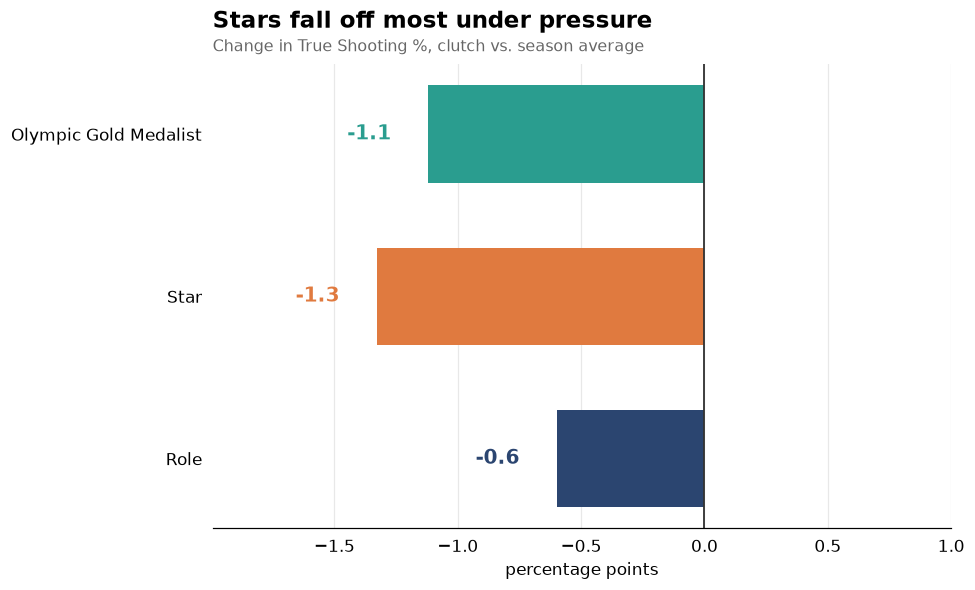

In [150]:
order = ['Role', 'Star', 'Olympic Gold Medalist']
d = (df.groupby('group')['TS_DELTA'].mean() * 100).reindex(order)

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(order, d.values, color=[TIER_C[g] for g in order], height=0.6)
ax.axvline(0, color='#333', linewidth=1.2)

for bar, val in zip(bars, d.values):
    ax.text(val + (0.15 if val >= 0 else -0.15), bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}', va='center', ha='left' if val >= 0 else 'right',
            fontweight='bold', fontsize=13, color=bar.get_facecolor())

titled(ax, 'Stars fall off most under pressure',
       'Change in True Shooting %, clutch vs. season average')
ax.set_xlabel('percentage points')
ax.set_xlim(min(d.min()*1.5, -1), max(d.max()*1.6, 1))
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

## Key Insight 2 — Stars Get More Shots and Make Fewer of Them

`Chart 8`

When games get close and late, offenses shift possession toward stars and away
from role players. Star usage climbs in the clutch while role player usage
drops — the ball is being deliberately funneled upward through the reputation
hierarchy.

The problem: star shooting efficiency moves in the opposite direction of their
usage. More shots, worse results. Role players lose the ball at the same moment
their shooting would suggest they've earned more of it.

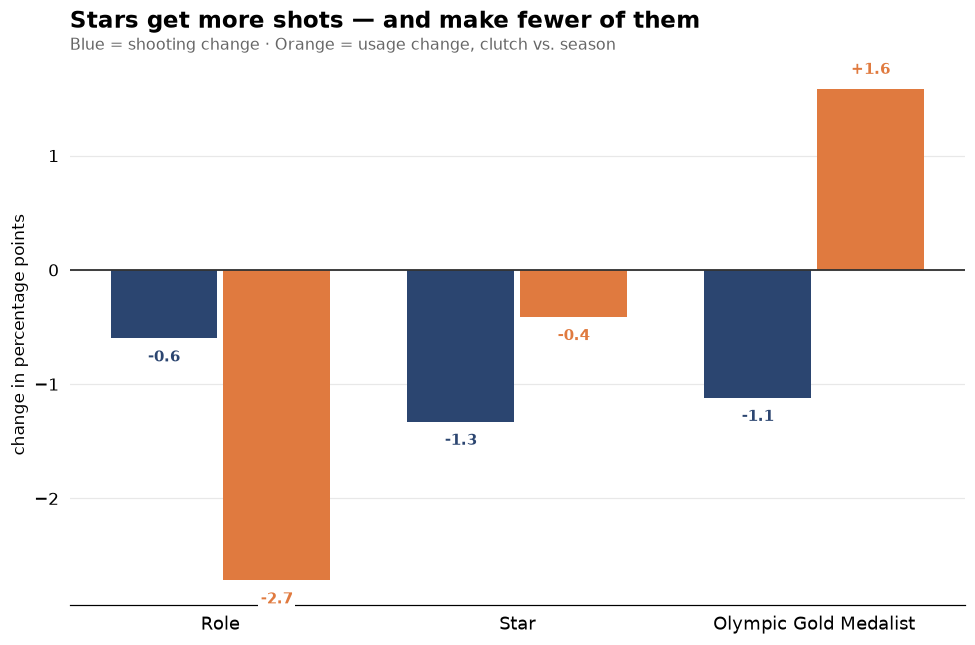

In [151]:
ts_d  = (df.groupby('group')['TS_DELTA'].mean() * 100).reindex(order)
usg_d = (df.groupby('group')['USG_DELTA'].mean() * 100).reindex(order)

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(order))

ax.bar(x - 0.19, ts_d, 0.36, color=NAVY, label='Shooting %')
ax.bar(x + 0.19, usg_d, 0.36, color=ORANGE, label='Usage %')
ax.axhline(0, color='#333', linewidth=1.2)

label_box = dict(facecolor='white', edgecolor='none', pad=1.5)

for xi, (t, u) in enumerate(zip(ts_d, usg_d)):
    ax.text(xi - 0.19, t + (0.10 if t >= 0 else -0.10), f'{t:+.1f}',
            ha='center', va='bottom' if t >= 0 else 'top', fontsize=10,
            color=NAVY, fontweight='bold', bbox=label_box)
    ax.text(xi + 0.19, u + (0.10 if u >= 0 else -0.10), f'{u:+.1f}',
            ha='center', va='bottom' if u >= 0 else 'top', fontsize=10,
            color=ORANGE, fontweight='bold', bbox=label_box)

ax.set_xticks(x); ax.set_xticklabels(order, fontsize=12)
ax.set_ylabel('change in percentage points')
titled(ax, 'Stars get more shots — and make fewer of them',
       'Blue = shooting change · Orange = usage change, clutch vs. season')
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.show()

## Key Insight 3 — Who Produces the Biggest Clutch Swings?

`Chart 9 & 10`

Counting how often each tier appears among the 15 biggest clutch risers and
15 biggest fallers — 30 slots total. Because Role players vastly outnumber
Star and Olympic Gold Medalist player-seasons in this dataset, raw counts
here mostly reflect population size rather than a tier-specific tendency to
swing big — see the per-tier and volume-filtered versions later in this
notebook for a fairer comparison across tiers.

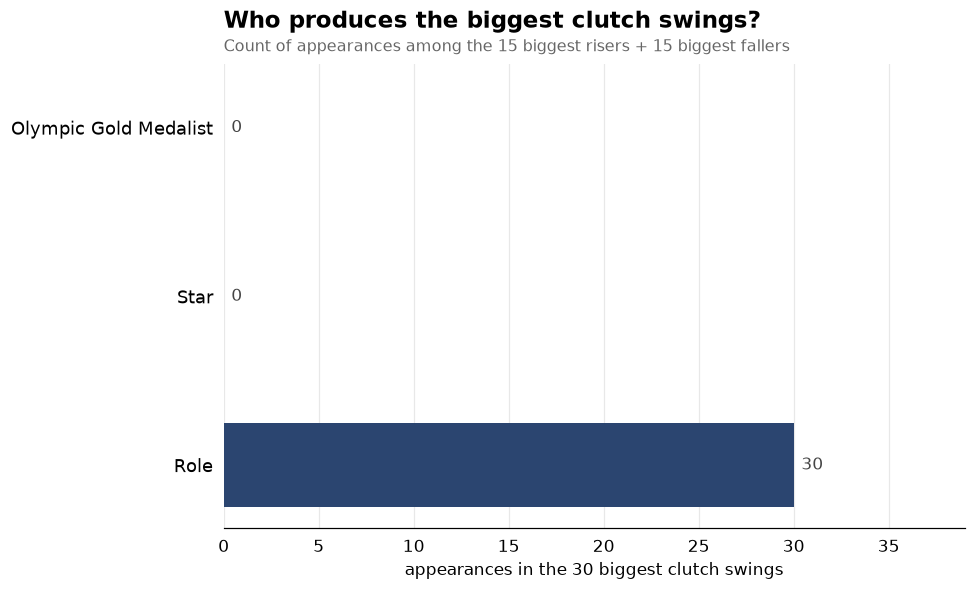

In [152]:
risers  = df.nlargest(15, 'TS_DELTA')['group'].value_counts().reindex(order, fill_value=0)
fallers = df.nsmallest(15, 'TS_DELTA')['group'].value_counts().reindex(order, fill_value=0)
actual  = risers + fallers

fig, ax = plt.subplots(figsize=(9, 5.5))
y = np.arange(len(order))

ax.barh(y, actual, 0.5, color=[TIER_C[g] for g in order])

for yi, a in enumerate(actual):
    ax.text(a + 0.4, yi, f'{a:.0f}', va='center', fontsize=11, color='#444')

ax.set_yticks(y); ax.set_yticklabels(order, fontsize=12)
ax.set_xlabel('appearances in the 30 biggest clutch swings')
titled(ax, 'Who produces the biggest clutch swings?',
       'Count of appearances among the 15 biggest risers + 15 biggest fallers')
ax.set_xlim(0, actual.max() * 1.3)
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

### Digging into the extremes
Before writing any conclusions about *why* the top risers/fallers performed
the way they did, pull their underlying usage, shot volume, and net rating —
raw TS_DELTA alone can't distinguish a real performance from a small-sample
artifact.

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


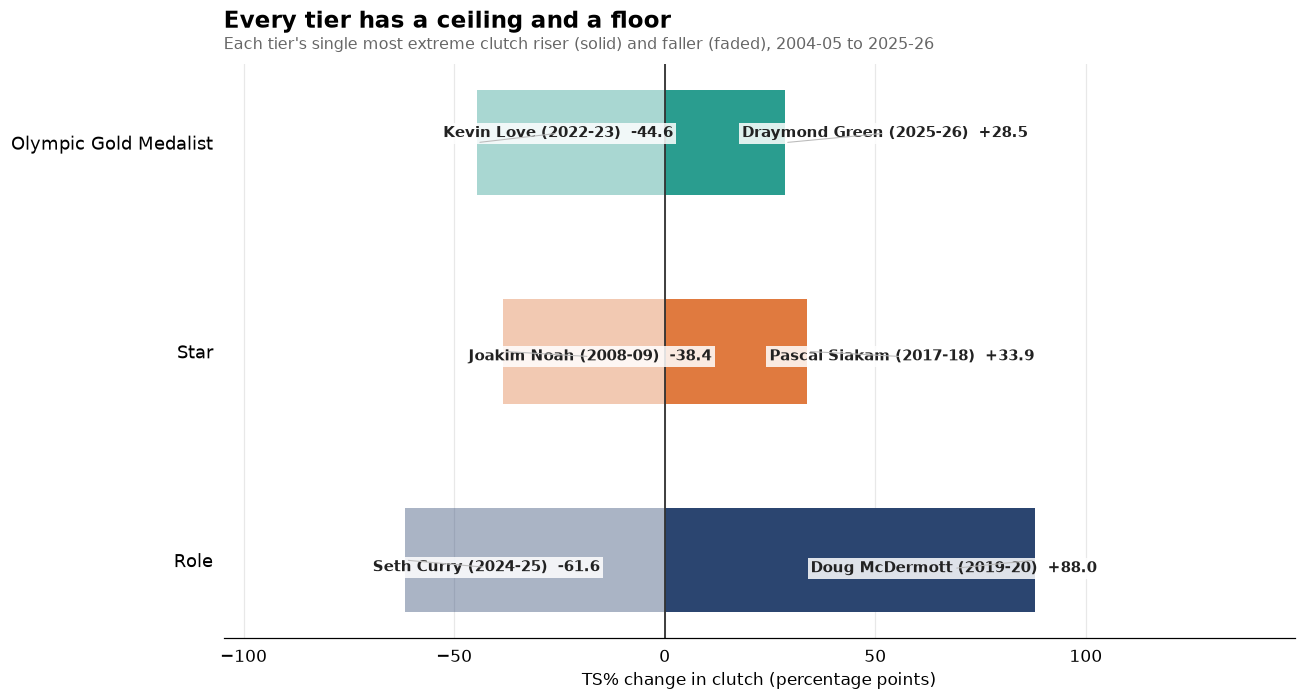

In [153]:
best_riser = df.loc[df.groupby('group')['TS_DELTA'].idxmax()].set_index('group').reindex(order)
worst_faller = df.loc[df.groupby('group')['TS_DELTA'].idxmin()].set_index('group').reindex(order)

fig, ax = plt.subplots(figsize=(12, 6.5))
y = np.arange(len(order))

ax.barh(y, best_riser['TS_DELTA'] * 100, height=0.5, color=[TIER_C[g] for g in order])
ax.barh(y, worst_faller['TS_DELTA'] * 100, height=0.5, color=[TIER_C[g] for g in order], alpha=0.4)
ax.axvline(0, color='#333', linewidth=1.2)

label_box = dict(facecolor='white', edgecolor='none', alpha=0.85, pad=2)

texts = []
for yi, g in enumerate(order):
    r, f = best_riser.loc[g], worst_faller.loc[g]
    texts.append(ax.text(r['TS_DELTA'] * 100, yi,
                 f"{r['PLAYER_NAME']} ({r['SEASON']})  +{r['TS_DELTA']*100:.1f}",
                 va='center', fontsize=9.5, color='#222', fontweight='bold',
                 bbox=label_box))
    texts.append(ax.text(f['TS_DELTA'] * 100, yi,
                 f"{f['PLAYER_NAME']} ({f['SEASON']})  {f['TS_DELTA']*100:.1f}",
                 va='center', fontsize=9.5, color='#222', fontweight='bold',
                 bbox=label_box))

adjust_text(texts, ax=ax,
            arrowprops=dict(arrowstyle='-', color='#bbb', lw=0.7),
            expand_points=(1.3, 1.6),
            only_move={'points': 'y', 'text': 'xy'})

ax.set_yticks(y); ax.set_yticklabels(order, fontsize=12)
ax.set_xlabel('TS% change in clutch (percentage points)')
ax.set_xlim(worst_faller['TS_DELTA'].min() * 100 * 1.7, best_riser['TS_DELTA'].max() * 100 * 1.7)
titled(ax, 'Every tier has a ceiling and a floor',
       "Each tier's single most extreme clutch riser (solid) and faller (faded), 2004-05 to 2025-26")
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

## Key Insight 4 — Home Court Helps, But Roughly Equally Across Tiers

`Chart 12`

All three tiers shoot better in clutch situations at home than on the road.
The gap is real, but similar in size across Role, Star, and Olympic Gold
Medalist alike — check the actual bar values before trusting that "roughly
equal" claim, since it was originally written for a two-tier comparison.

This rules out venue as an explanation for the other findings in this
notebook. Whatever is driving the efficiency and usage patterns elsewhere,
it isn't crowd or travel.

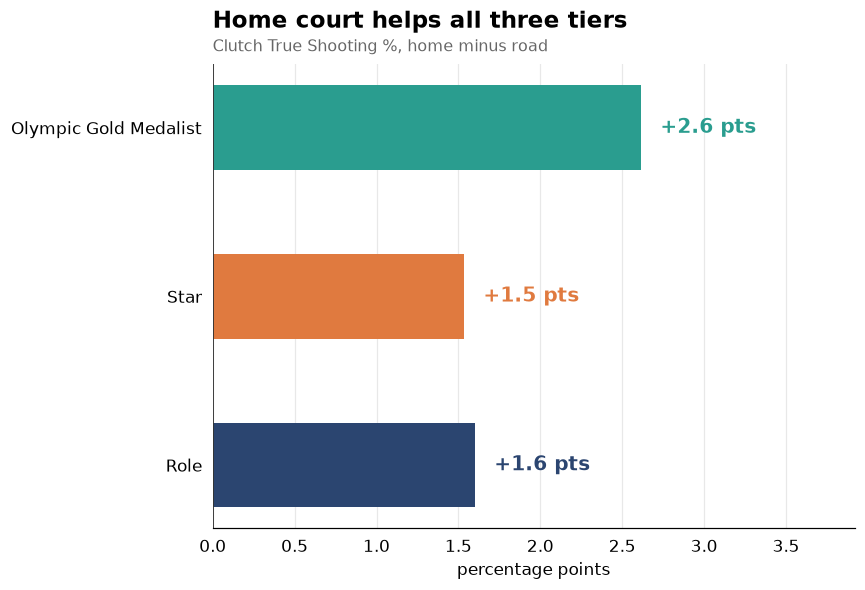

In [166]:
gap = (hr.groupby('group')['TS_HOME_ROAD_GAP'].mean() * 100).reindex(['Role', 'Star', 'Olympic Gold Medalist'])

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.barh(gap.index, gap.values, color=[TIER_C[g] for g in gap.index], height=0.5)
ax.axvline(0, color='#333', linewidth=1.2)

for bar, val in zip(bars, gap.values):
    ax.text(val + 0.12, bar.get_y() + bar.get_height()/2, f'+{val:.1f} pts',
            va='center', fontweight='bold', fontsize=13, color=bar.get_facecolor())

titled(ax, 'Home court helps all three tiers',
       'Clutch True Shooting %, home minus road')
ax.set_xlabel('percentage points')
ax.set_xlim(0, gap.max() * 1.5)
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

## Key Insight 5 — At the Top, Role Players Out-Shoot Stars and Still Get Fewer Shots

`Chart 18 & 20`

Among the most efficient shooters in the league this season (top 20% by
season TS%), role players post a higher clutch True Shooting % than stars.
At the same time, their clutch usage gets cut the hardest of any quintile —
the offense pulls the ball away from them even as the numbers say they've
earned it.

The shaded band marks this top quintile in both panels. Watch what happens
there: the shooting lines cross (role above star) while the usage lines stay
fixed apart (star well above role). The allocation and the performance are
moving in opposite directions.

This is the clearest version of the reputation-vs-performance gap this
project set out to test: at the skill level where the data most strongly
supports giving a role player the ball, the offense does the opposite.

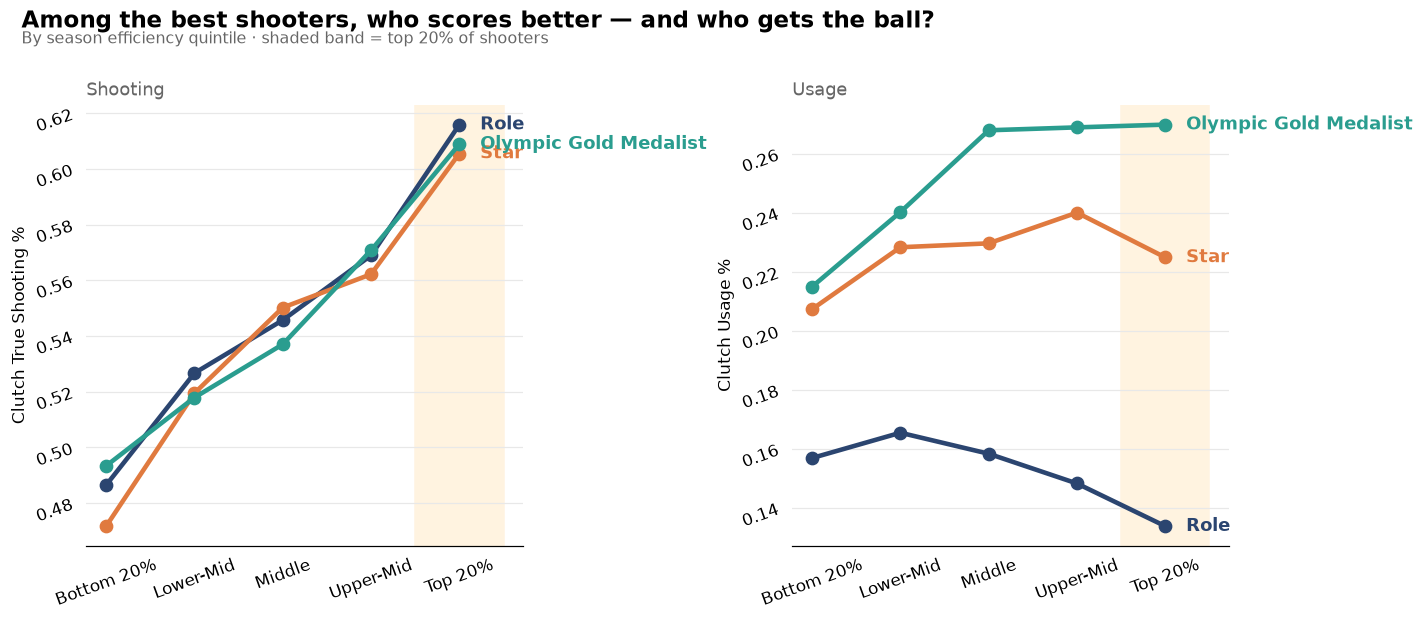

In [155]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True)
xl = [str(i) for i in qt.index]

for tier in ['Role', 'Star', 'Olympic Gold Medalist']:
    if tier not in qt.columns:
        continue
    s = qt[tier].dropna()
    if len(s) < 2:
        continue
    a1.plot([str(i) for i in s.index], s.values, marker='o', markersize=8,
            linewidth=3, color=TIER_C[tier])
    a1.text(len(s) - 0.9, s.values[-1], f'  {tier}', color=TIER_C[tier],
            fontweight='bold', va='center', fontsize=12)

for tier in ['Role', 'Star', 'Olympic Gold Medalist']:
    sub = uq.xs(tier, level='group')
    a2.plot(xl, sub['USG_PCT_CLUTCH'].values, marker='o', markersize=8,
            linewidth=3, color=TIER_C[tier])
    a2.text(len(xl) - 0.9, sub['USG_PCT_CLUTCH'].values[-1], f'  {tier}',
            color=TIER_C[tier], fontweight='bold', va='center', fontsize=12)

for a in (a1, a2):
    a.axvspan(3.5, 4.5, color='#FFF3E0', zorder=0)
    a.tick_params(labelrotation=20)
    a.grid(axis='x', visible=False)

a1.set_ylabel('Clutch True Shooting %')
a2.set_ylabel('Clutch Usage %')
a1.set_title('Shooting', fontsize=12, color='#666', loc='left')
a2.set_title('Usage', fontsize=12, color='#666', loc='left')

fig.suptitle('Among the best shooters, who scores better — and who gets the ball?',
             fontsize=15, fontweight='bold', x=0.02, ha='left', y=1.02)
fig.text(0.02, 0.965, 'By season efficiency quintile · shaded band = top 20% of shooters',
         fontsize=10.5, color='#666')
plt.tight_layout()
plt.show()

In [156]:
risers_detail = df.nlargest(10, 'TS_DELTA')[[
    'PLAYER_NAME', 'group', 'TS_PCT_SEASON', 'TS_PCT_CLUTCH',
    'TS_DELTA', 'USG_PCT_SEASON', 'USG_PCT_CLUTCH', 'USG_DELTA',
    'NET_RATING_CLUTCH', 'PIE_CLUTCH', 'GP_CLUTCH'
]]

fallers_detail = df.nsmallest(10, 'TS_DELTA')[[
    'PLAYER_NAME', 'group', 'TS_PCT_SEASON', 'TS_PCT_CLUTCH',
    'TS_DELTA', 'USG_PCT_SEASON', 'USG_PCT_CLUTCH', 'USG_DELTA',
    'NET_RATING_CLUTCH', 'PIE_CLUTCH', 'GP_CLUTCH'
]]

print("RISERS")
print(risers_detail.to_string())
print("\nFALLERS")
print(fallers_detail.to_string())

RISERS
          PLAYER_NAME group  TS_PCT_SEASON  TS_PCT_CLUTCH  TS_DELTA  USG_PCT_SEASON  USG_PCT_CLUTCH  USG_DELTA  NET_RATING_CLUTCH  PIE_CLUTCH  GP_CLUTCH
5511   Doug McDermott  Role          0.620          1.500     0.880           0.186           0.068     -0.118               14.7       0.279         15
2484   Damien Wilkins  Role          0.445          1.136     0.691           0.123           0.100     -0.023              -72.3       0.029         15
2822  Charles Jenkins  Role          0.425          1.042     0.617           0.145           0.095     -0.050               19.8       0.471         15
1971     Quinton Ross  Role          0.393          1.000     0.607           0.101           0.068     -0.033              -12.7      -0.070         15
3983    Dwight Powell  Role          0.557          1.136     0.579           0.175           0.091     -0.084               -7.2       0.070         19
1800  DeMarre Carroll  Role          0.426          1.000     0.574        

## Key Insight 6 — Why Are These Players Overperforming/Underperforming

**⚠ Needs a rewrite once cell 88 is rerun.** This markdown was written
against the original single-season dataset (Jaren Jackson Jr., specific
single-year numbers). With 22 seasons of data now feeding `df`, the top 10
risers/fallers here are almost certainly different players from different
eras — rerun cell 88, read the actual names and usage/efficiency numbers
that come back, and rewrite this section to match. Don't reuse the old
narrative with new numbers swapped in; check whether the *pattern* (usage
drops for risers, stays flat or rises for fallers) still holds at all before
restating it as a finding.

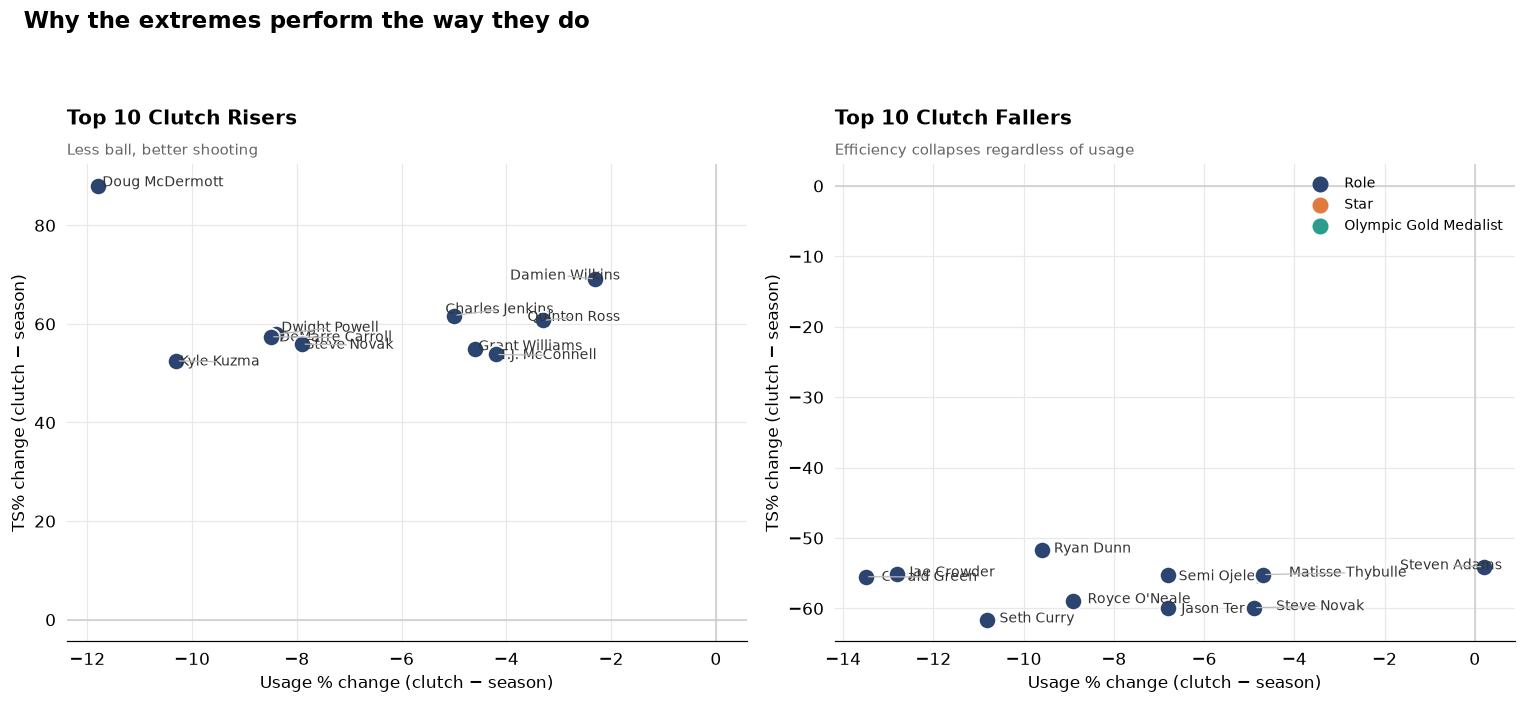

In [157]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, subset, title, note in [
    (a1, df.nlargest(10, 'TS_DELTA'), 'Top 10 Clutch Risers', 'Less ball, better shooting'),
    (a2, df.nsmallest(10, 'TS_DELTA'), 'Top 10 Clutch Fallers', 'Efficiency collapses regardless of usage')
]:
    s = subset.copy()
    s['TS_DELTA'] *= 100
    s['USG_DELTA'] *= 100

    texts = []
    for _, row in s.iterrows():
        ax.scatter(row['USG_DELTA'], row['TS_DELTA'],
                   color=TIER_C[row['group']], s=130, zorder=3,
                   edgecolor='white', linewidth=1.2)
        texts.append(ax.text(row['USG_DELTA'], row['TS_DELTA'],
                             row['PLAYER_NAME'], fontsize=9, color='#333'))

    adjust_text(texts, ax=ax,
                arrowprops=dict(arrowstyle='-', color='#bbb', lw=0.8),
                expand_points=(1.4, 1.4))

    ax.axhline(0, color='#ccc', linewidth=1, zorder=1)
    ax.axvline(0, color='#ccc', linewidth=1, zorder=1)
    ax.set_xlabel('Usage % change (clutch − season)')
    ax.set_ylabel('TS% change (clutch − season)')
    ax.set_title(title, fontweight='bold', loc='left', fontsize=13, pad=26)
    ax.text(0, 1.02, note, transform=ax.transAxes, fontsize=9.5, color='#666')

for tier, color in TIER_C.items():
    a2.scatter([], [], color=color, label=tier, s=90)
a2.legend(loc='upper right', frameon=False, fontsize=9)

fig.suptitle('Why the extremes perform the way they do',
             fontsize=15, fontweight='bold', x=0.02, ha='left', y=1.06)
plt.tight_layout()
plt.show()

### Chart — Extremes, per tier, unfiltered
Same per-tier fix as Charts 9b/10b, applied to the usage-vs-efficiency scatter
instead of the ranked bar chart. Each point is one player-season; risers on
the left, fallers on the right, 5 per tier in each panel.

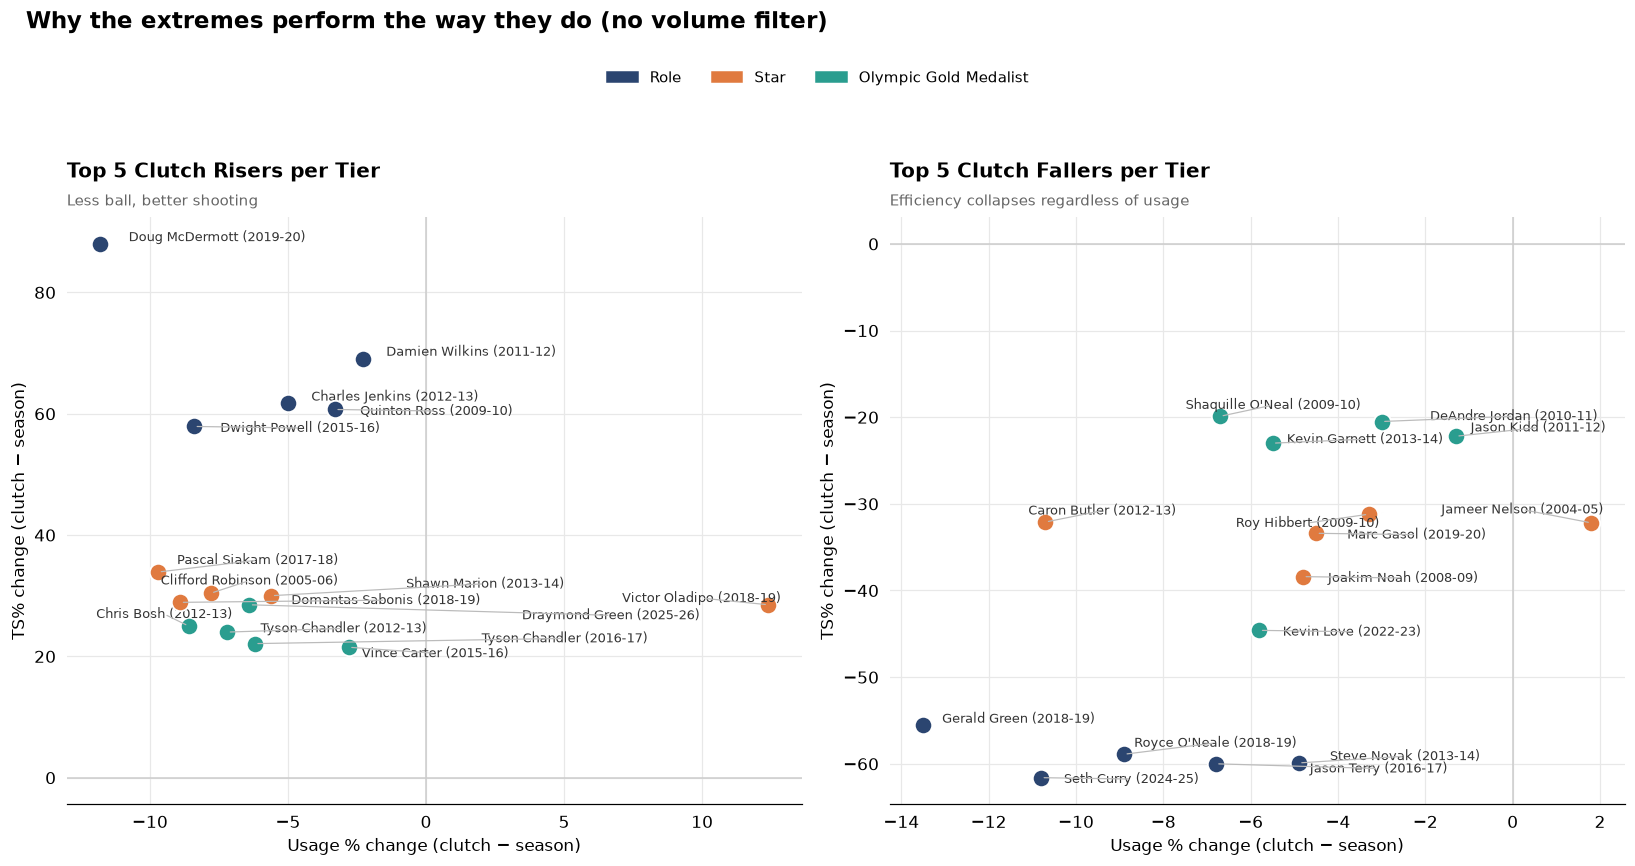

In [158]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 7))

for ax, subset, title, note in [
    (a1, risers_per_tier, 'Top 5 Clutch Risers per Tier', 'Less ball, better shooting'),
    (a2, fallers_per_tier, 'Top 5 Clutch Fallers per Tier', 'Efficiency collapses regardless of usage')
]:
    s = subset.copy()
    s['TS_DELTA'] *= 100
    s['USG_DELTA'] *= 100

    texts = []
    for _, row in s.iterrows():
        ax.scatter(row['USG_DELTA'], row['TS_DELTA'],
                   color=TIER_C[row['group']], s=130, zorder=3,
                   edgecolor='white', linewidth=1.2)
        texts.append(ax.text(row['USG_DELTA'], row['TS_DELTA'],
                             f"{row['PLAYER_NAME']} ({row['SEASON']})", fontsize=8.5, color='#333'))

    adjust_text(texts, ax=ax,
                arrowprops=dict(arrowstyle='-', color='#bbb', lw=0.8),
                expand_points=(1.4, 1.4))

    ax.axhline(0, color='#ccc', linewidth=1, zorder=1)
    ax.axvline(0, color='#ccc', linewidth=1, zorder=1)
    ax.set_xlabel('Usage % change (clutch − season)')
    ax.set_ylabel('TS% change (clutch − season)')
    ax.set_title(title, fontweight='bold', loc='left', fontsize=13, pad=26)
    ax.text(0, 1.02, note, transform=ax.transAxes, fontsize=9.5, color='#666')

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in TIER_C.values()]
fig.legend(handles, TIER_C.keys(), loc='upper center', bbox_to_anchor=(0.5, 1.06),
           ncol=3, frameon=False, fontsize=10)

fig.suptitle('Why the extremes perform the way they do (no volume filter)',
             fontsize=15, fontweight='bold', x=0.02, ha='left', y=1.12)
plt.tight_layout()
plt.show()

## Key Insight 7 — Has the Reputation Gap Changed Over Two Decades?

`Chart — Trend Analysis`

This is the one comparison the single-season version of this notebook
couldn't make. Tracking each tier's average clutch efficiency and usage shift
season by season (smoothed with a 3-season rolling average, since single-year
tier samples — especially Olympic Gold Medalist — are small enough to be
noisy on their own) shows whether the patterns found elsewhere in this
notebook are a constant feature of the league or have shifted as the NBA
itself has changed.

**Check `trend_counts` before reading the lines.** Any season/tier cell with
a thin count should be treated as unreliable for that stretch, smoothing or not.## Key Insight 7 — Has the Reputation Gap Changed Over Two Decades?

`Chart — Trend Analysis`

This is the one comparison the single-season version of this notebook
couldn't make. Tracking each tier's average clutch efficiency and usage shift
season by season (smoothed with a 3-season rolling average, since single-year
tier samples — especially Olympic Gold Medalist — are small enough to be
noisy on their own) shows whether the patterns found elsewhere in this
notebook are a constant feature of the league or have shifted as the NBA
itself has changed.

**Check `trend_counts` before reading the lines.** Any season/tier cell with
a thin count should be treated as unreliable for that stretch, smoothing or not.

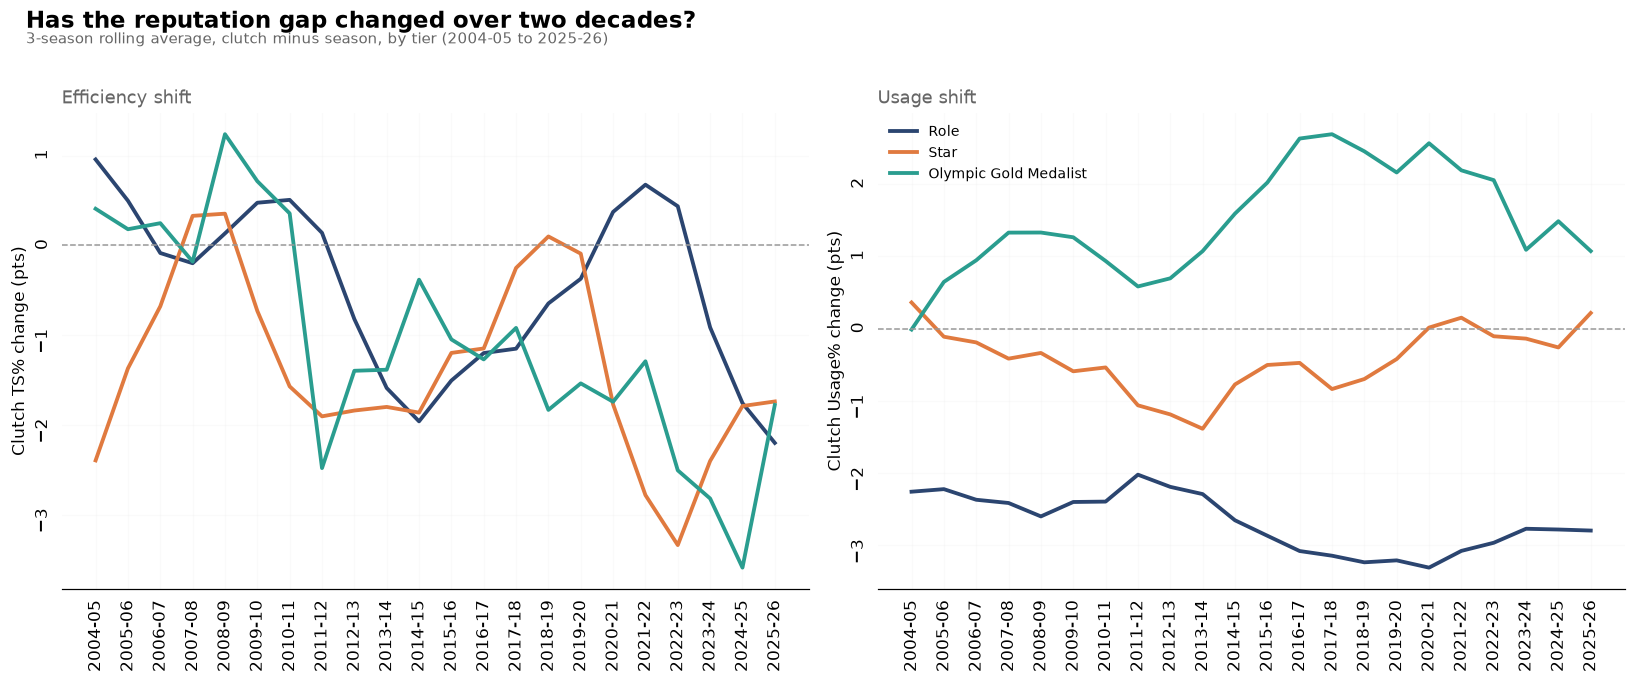

group    Olympic Gold Medalist  Role  Star
SEASON                                    
2004-05                     24   181    52
2005-06                     21   168    55
2006-07                     23   166    56
2007-08                     22   162    50
2008-09                     24   156    51
2009-10                     26   150    52
2010-11                     28   156    46
2011-12                     28   142    42
2012-13                     32   164    43
2013-14                     32   158    40
2014-15                     30   172    42
2015-16                     32   169    40
2016-17                     30   176    41
2017-18                     30   172    42
2018-19                     26   171    42
2019-20                     22   144    44
2020-21                     26   137    41
2021-22                     24   158    41
2022-23                     24   160    44
2023-24                     22   145    47
2024-25                     22   157    42
2025-26    

In [159]:
trend_ts = df.groupby(['SEASON', 'group'], observed=True)['TS_DELTA'].mean().unstack() * 100
trend_usg = df.groupby(['SEASON', 'group'], observed=True)['USG_DELTA'].mean().unstack() * 100
trend_counts = df.groupby(['SEASON', 'group'], observed=True).size().unstack(fill_value=0)

# Smooth with a 3-season rolling average — single-season tier samples are small,
# especially for Olympic Gold Medalist, and raw year-to-year values will be noisy
trend_ts_smooth = trend_ts.rolling(3, min_periods=1).mean()
trend_usg_smooth = trend_usg.rolling(3, min_periods=1).mean()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

for tier in ['Role', 'Star', 'Olympic Gold Medalist']:
    if tier in trend_ts_smooth.columns:
        a1.plot(trend_ts_smooth.index, trend_ts_smooth[tier], color=TIER_C[tier], linewidth=2.5, label=tier)
    if tier in trend_usg_smooth.columns:
        a2.plot(trend_usg_smooth.index, trend_usg_smooth[tier], color=TIER_C[tier], linewidth=2.5, label=tier)

for a in (a1, a2):
    a.axhline(0, color='#999', linewidth=1, linestyle='--')
    a.tick_params(labelrotation=90)
    a.grid(alpha=0.2)

a1.set_ylabel('Clutch TS% change (pts)')
a2.set_ylabel('Clutch Usage% change (pts)')
a1.set_title('Efficiency shift', loc='left', fontsize=12, color='#666')
a2.set_title('Usage shift', loc='left', fontsize=12, color='#666')
a2.legend(loc='upper left', frameon=False, fontsize=9)

fig.suptitle('Has the reputation gap changed over two decades?',
             fontsize=15, fontweight='bold', x=0.02, ha='left', y=1.03)
fig.text(0.02, 0.98, '3-season rolling average, clutch minus season, by tier (2004-05 to 2025-26)',
         fontsize=10, color='#666')
plt.tight_layout()
plt.show()

print(trend_counts)

### Pulling the real numbers behind each tier's extreme
Before trusting the ceiling/floor chart, check what's actually driving each
tier's single most extreme riser and faller — specifically their clutch shot
volume (`FGA_CLUTCH`). A large TS_DELTA built on very few shots is a
different kind of finding than one built on real volume.

In [160]:
detail_cols = ['PLAYER_NAME', 'SEASON', 'group', 'TS_PCT_SEASON', 'TS_PCT_CLUTCH',
               'TS_DELTA', 'USG_PCT_SEASON', 'USG_PCT_CLUTCH', 'USG_DELTA',
               'FGA_CLUTCH', 'GP_CLUTCH', 'NET_RATING_CLUTCH', 'PIE_CLUTCH']

extremes_detail = pd.concat([
    best_riser.reset_index()[detail_cols],
    worst_faller.reset_index()[detail_cols]
], keys=['Riser', 'Faller']).reset_index(level=0).rename(columns={'level_0': 'type'})

print(extremes_detail.to_string(index=False))

  type    PLAYER_NAME  SEASON                 group  TS_PCT_SEASON  TS_PCT_CLUTCH  TS_DELTA  USG_PCT_SEASON  USG_PCT_CLUTCH  USG_DELTA  FGA_CLUTCH  GP_CLUTCH  NET_RATING_CLUTCH  PIE_CLUTCH
 Riser Doug McDermott 2019-20                  Role          0.620          1.500     0.880           0.186           0.068     -0.118           3         15               14.7       0.279
 Riser  Pascal Siakam 2017-18                  Star          0.549          0.888     0.339           0.154           0.057     -0.097           7         31              -18.9       0.081
 Riser Draymond Green 2025-26 Olympic Gold Medalist          0.540          0.825     0.285           0.158           0.094     -0.064          13         28               -3.5       0.095
Faller     Seth Curry 2024-25                  Role          0.616          0.000    -0.616           0.151           0.043     -0.108           2         16              -19.9      -0.091
Faller    Joakim Noah 2008-09                  Star    

### Checking how much each tier survives a shot-volume floor
Before picking a cutoff, confirm no tier gets wiped out by it — Olympic Gold
Medalist is the thinnest tier to begin with.

In [161]:
for floor in [10, 15, 20, 25]:
    counts = df[df['FGA_CLUTCH'] >= floor]['group'].value_counts().reindex(order, fill_value=0)
    print(f"FGA_CLUTCH >= {floor}: {dict(counts)}")

FGA_CLUTCH >= 10: {'Role': np.int64(2822), 'Star': np.int64(959), 'Olympic Gold Medalist': np.int64(535)}
FGA_CLUTCH >= 15: {'Role': np.int64(2216), 'Star': np.int64(900), 'Olympic Gold Medalist': np.int64(509)}
FGA_CLUTCH >= 20: {'Role': np.int64(1729), 'Star': np.int64(838), 'Olympic Gold Medalist': np.int64(470)}
FGA_CLUTCH >= 25: {'Role': np.int64(1309), 'Star': np.int64(762), 'Olympic Gold Medalist': np.int64(437)}


### Rebuilding the extremes with a shot-volume floor
`FGA_CLUTCH >= 20` removes the low-volume artifacts found above (a handful of
shots producing an artificially huge or tiny TS_DELTA). `df_vol` becomes the
trustworthy version of `df` for any "biggest swing" chart from here forward.

In [162]:
FGA_FLOOR = 20
df_vol = df[df['FGA_CLUTCH'] >= FGA_FLOOR]

best_riser_vol = df_vol.loc[df_vol.groupby('group')['TS_DELTA'].idxmax()].set_index('group').reindex(order)
worst_faller_vol = df_vol.loc[df_vol.groupby('group')['TS_DELTA'].idxmin()].set_index('group').reindex(order)

detail_cols = ['PLAYER_NAME', 'SEASON', 'group', 'TS_DELTA', 'USG_DELTA', 'FGA_CLUTCH', 'GP_CLUTCH', 'NET_RATING_CLUTCH']

extremes_vol_detail = pd.concat([
    best_riser_vol.reset_index()[detail_cols],
    worst_faller_vol.reset_index()[detail_cols]
], keys=['Riser', 'Faller']).reset_index(level=0).rename(columns={'level_0': 'type'})

print(extremes_vol_detail.to_string(index=False))

  type      PLAYER_NAME  SEASON                 group  TS_DELTA  USG_DELTA  FGA_CLUTCH  GP_CLUTCH  NET_RATING_CLUTCH
 Riser    Eddie Griffin 2004-05                  Role     0.303     -0.011          22         28               25.0
 Riser     Shawn Marion 2013-14                  Star     0.300     -0.056          21         40               12.8
 Riser       Chris Bosh 2012-13 Olympic Gold Medalist     0.250     -0.086          35         35               30.1
Faller    Devin Vassell 2021-22                  Role    -0.414     -0.068          22         26              -23.0
Faller    Jameer Nelson 2004-05                  Star    -0.322      0.018          20         23              -29.2
Faller Jimmy Butler III 2021-22 Olympic Gold Medalist    -0.185      0.059          51         23                0.6


## Key Insight 8 — Real Extremes, Once Shot Volume Is Accounted For

`Chart — Ceiling/Floor, volume-filtered`

The unfiltered version of this chart included players who took as few as 2-3
clutch shots all season — enough for a hot or cold stretch to produce a
misleadingly large swing. This version requires at least 20 clutch shot
attempts before a player-season can appear as a tier's ceiling or floor.
Compare the two versions directly: if the extreme players and magnitudes
changed substantially, that's a real finding about the *original metric's*
limitations, worth stating plainly rather than glossing over.

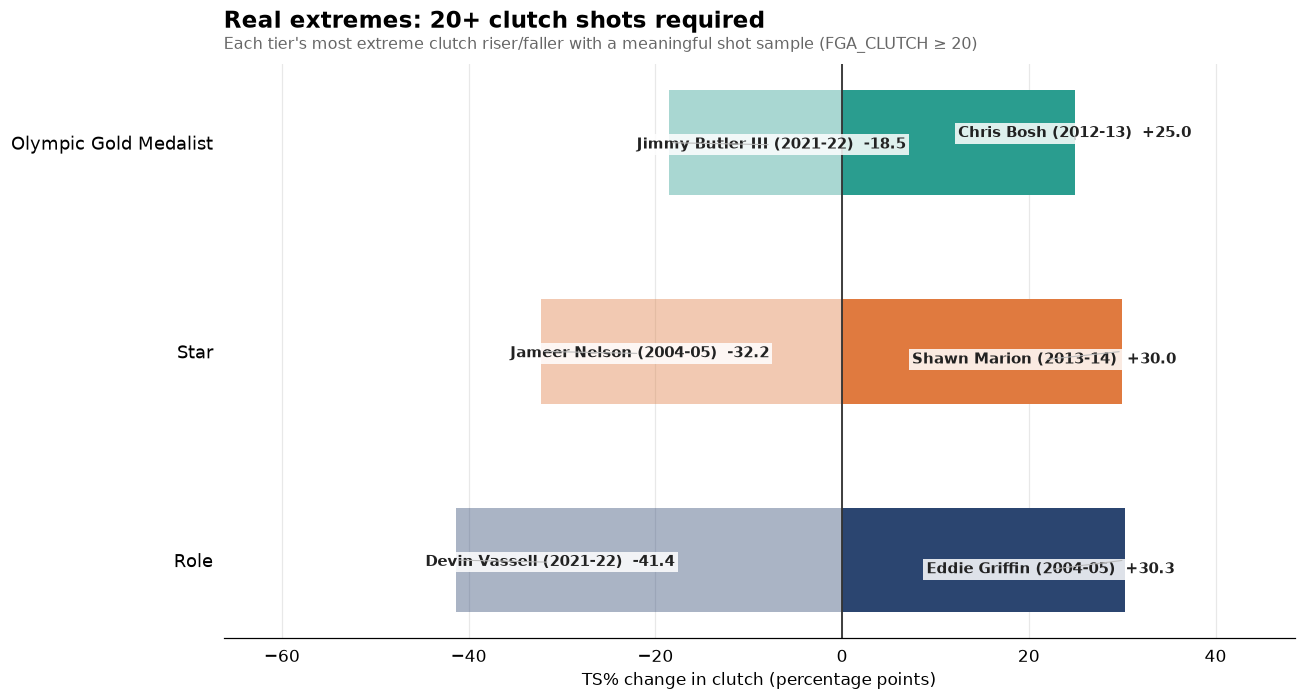

In [163]:
fig, ax = plt.subplots(figsize=(12, 6.5))
y = np.arange(len(order))

ax.barh(y, best_riser_vol['TS_DELTA'] * 100, height=0.5, color=[TIER_C[g] for g in order])
ax.barh(y, worst_faller_vol['TS_DELTA'] * 100, height=0.5, color=[TIER_C[g] for g in order], alpha=0.4)
ax.axvline(0, color='#333', linewidth=1.2)

label_box = dict(facecolor='white', edgecolor='none', alpha=0.85, pad=2)
texts = []
for yi, g in enumerate(order):
    r, f = best_riser_vol.loc[g], worst_faller_vol.loc[g]
    texts.append(ax.text(r['TS_DELTA'] * 100, yi,
                 f"{r['PLAYER_NAME']} ({r['SEASON']})  +{r['TS_DELTA']*100:.1f}",
                 va='center', fontsize=9.5, color='#222', fontweight='bold', bbox=label_box))
    texts.append(ax.text(f['TS_DELTA'] * 100, yi,
                 f"{f['PLAYER_NAME']} ({f['SEASON']})  {f['TS_DELTA']*100:.1f}",
                 va='center', fontsize=9.5, color='#222', fontweight='bold', bbox=label_box))

adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='#bbb', lw=0.7),
            expand_points=(1.3, 1.6), only_move={'points': 'y', 'text': 'xy'})

ax.set_yticks(y); ax.set_yticklabels(order, fontsize=12)
ax.set_xlabel('TS% change in clutch (percentage points)')
ax.set_xlim(worst_faller_vol['TS_DELTA'].min() * 100 * 1.6, best_riser_vol['TS_DELTA'].max() * 100 * 1.6)
titled(ax, 'Real extremes: 20+ clutch shots required',
       f'Each tier\'s most extreme clutch riser/faller with a meaningful shot sample (FGA_CLUTCH ≥ {FGA_FLOOR})')
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

### Chart 9c/10c — Biggest swings per tier, volume-filtered
Same per-tier top-5 structure as Charts 9b/10b, now pulling from `df_vol`
instead of `df` — every name shown took a real, meaningful number of clutch
shots.

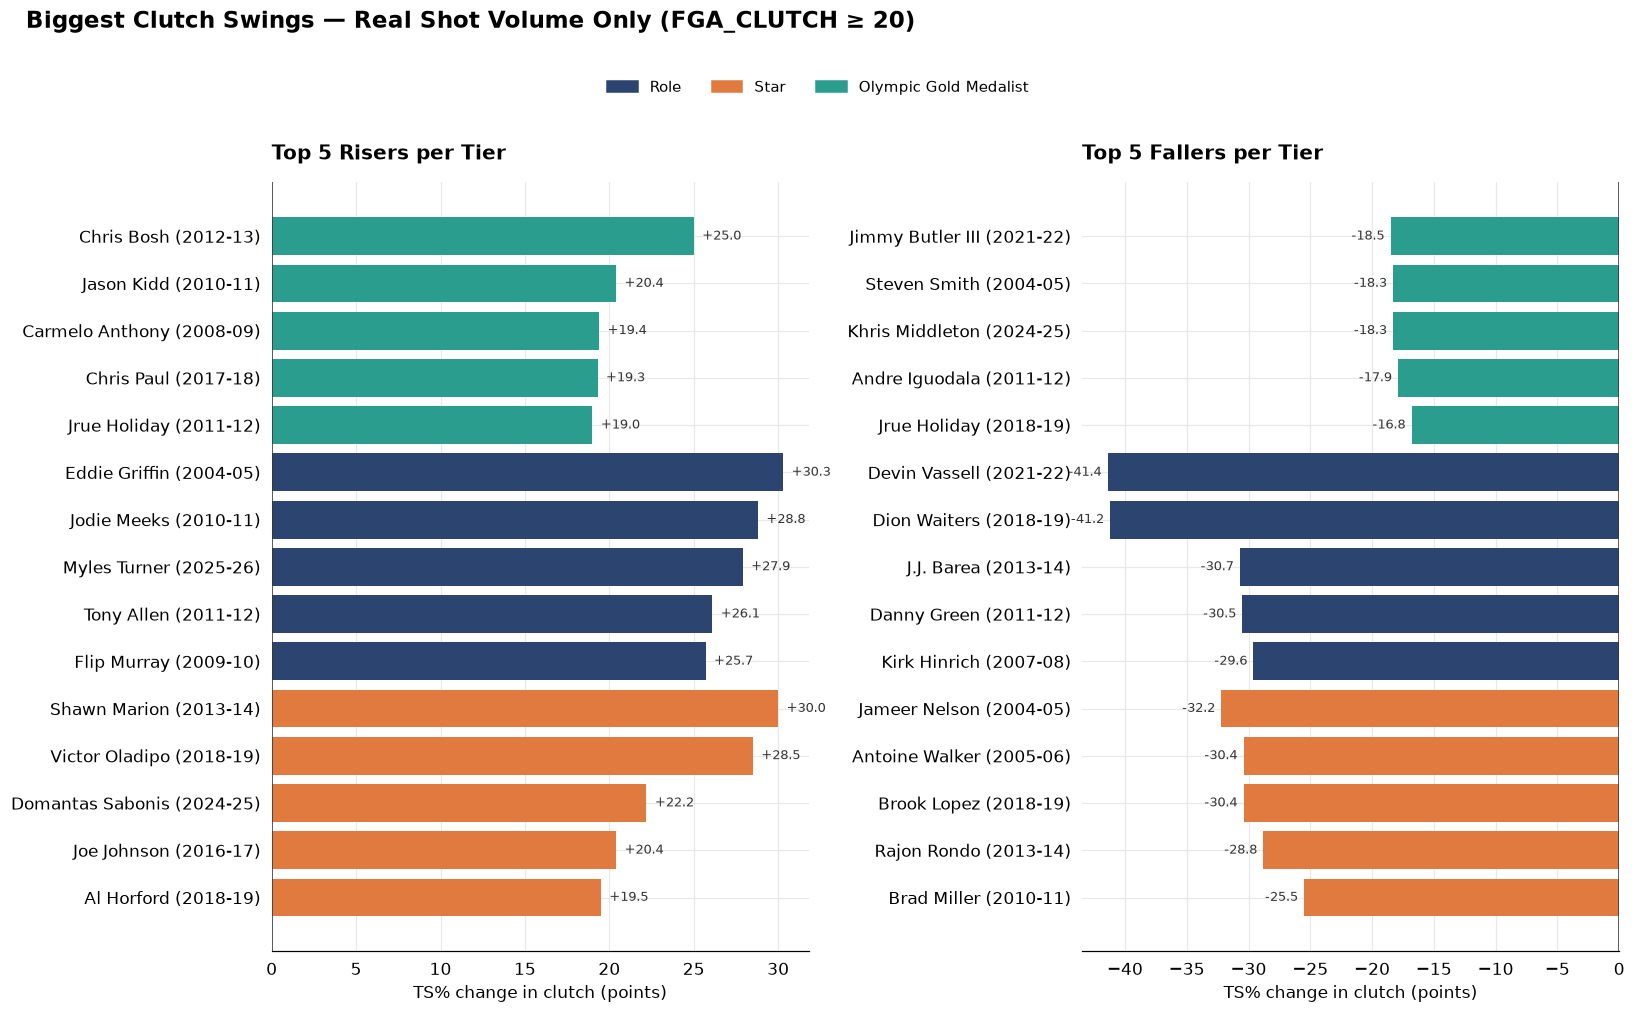

In [164]:
top_n = 5

risers_vol = (
    df_vol.sort_values('TS_DELTA', ascending=False)
          .groupby('group')
          .head(top_n)
          .sort_values(['group', 'TS_DELTA'], ascending=[True, False])
)
fallers_vol = (
    df_vol.sort_values('TS_DELTA', ascending=True)
          .groupby('group')
          .head(top_n)
          .sort_values(['group', 'TS_DELTA'], ascending=[True, True])
)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 8.5))

for ax, subset, title in [(a1, risers_vol, f'Top {top_n} Risers per Tier'),
                           (a2, fallers_vol, f'Top {top_n} Fallers per Tier')]:
    labels = subset['PLAYER_NAME'] + ' (' + subset['SEASON'] + ')'
    bar_colors = [TIER_C[g] for g in subset['group']]
    bars = ax.barh(labels, subset['TS_DELTA'] * 100, color=bar_colors)
    ax.invert_yaxis()
    ax.axvline(0, color='#333', linewidth=1)
    ax.set_xlabel('TS% change in clutch (points)')
    ax.set_title(title, fontweight='bold', loc='left', fontsize=13, pad=15)

    for bar, val in zip(bars, subset['TS_DELTA'] * 100):
        ax.text(val + (0.5 if val >= 0 else -0.5), bar.get_y() + bar.get_height()/2,
                f'{val:+.1f}', va='center', ha='left' if val >= 0 else 'right',
                fontsize=8.5, color='#333')

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in TIER_C.values()]
fig.legend(handles, TIER_C.keys(), loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=3, frameon=False, fontsize=10)

fig.suptitle(f'Biggest Clutch Swings — Real Shot Volume Only (FGA_CLUTCH ≥ {FGA_FLOOR})',
             fontsize=15, fontweight='bold', x=0.02, ha='left', y=1.08)
plt.tight_layout()
plt.show()

### Why the volume-filtered extremes perform the way they do
Same usage-vs-efficiency scatter as the earlier "why the extremes perform the
way they do" chart, rebuilt on `df_vol`. Compare directly against the
unfiltered version — if the story changes once low-volume flukes are removed,
say so explicitly in the final writeup.

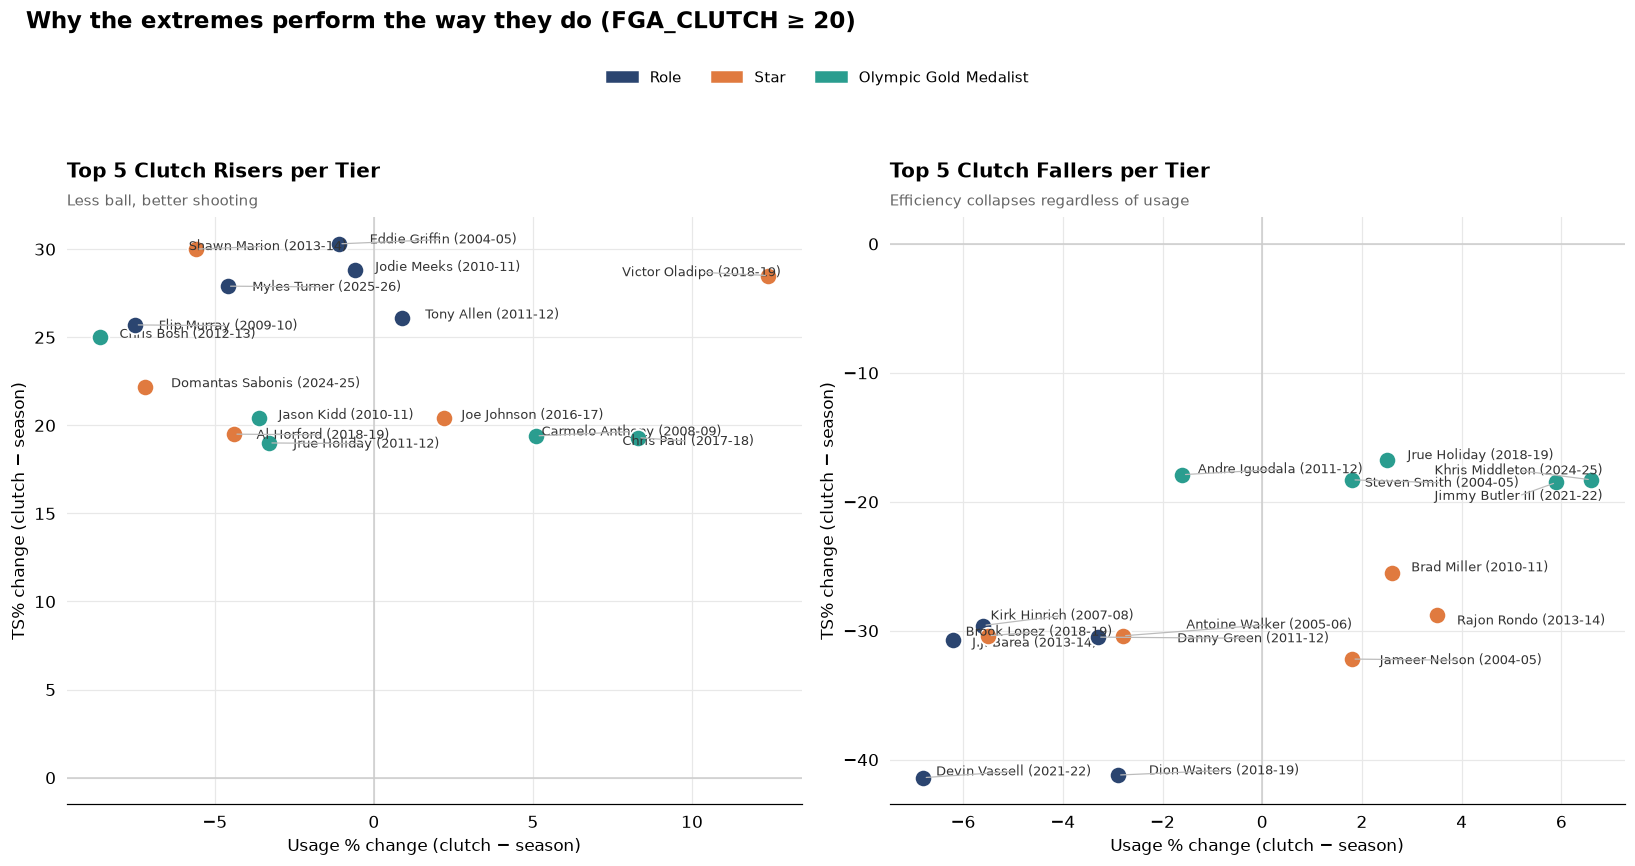

In [165]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 7))

for ax, subset, title, note in [
    (a1, risers_vol, 'Top 5 Clutch Risers per Tier', 'Less ball, better shooting'),
    (a2, fallers_vol, 'Top 5 Clutch Fallers per Tier', 'Efficiency collapses regardless of usage')
]:
    s = subset.copy()
    s['TS_DELTA'] *= 100
    s['USG_DELTA'] *= 100

    texts = []
    for _, row in s.iterrows():
        ax.scatter(row['USG_DELTA'], row['TS_DELTA'],
                   color=TIER_C[row['group']], s=130, zorder=3,
                   edgecolor='white', linewidth=1.2)
        texts.append(ax.text(row['USG_DELTA'], row['TS_DELTA'],
                             f"{row['PLAYER_NAME']} ({row['SEASON']})", fontsize=8.5, color='#333'))

    adjust_text(texts, ax=ax,
                arrowprops=dict(arrowstyle='-', color='#bbb', lw=0.8),
                expand_points=(1.4, 1.4))

    ax.axhline(0, color='#ccc', linewidth=1, zorder=1)
    ax.axvline(0, color='#ccc', linewidth=1, zorder=1)
    ax.set_xlabel('Usage % change (clutch − season)')
    ax.set_ylabel('TS% change (clutch − season)')
    ax.set_title(title, fontweight='bold', loc='left', fontsize=13, pad=26)
    ax.text(0, 1.02, note, transform=ax.transAxes, fontsize=9.5, color='#666')

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in TIER_C.values()]
fig.legend(handles, TIER_C.keys(), loc='upper center', bbox_to_anchor=(0.5, 1.06),
           ncol=3, frameon=False, fontsize=10)

fig.suptitle(f'Why the extremes perform the way they do (FGA_CLUTCH ≥ {FGA_FLOOR})',
             fontsize=15, fontweight='bold', x=0.02, ha='left', y=1.12)
plt.tight_layout()
plt.show()